# Hyperparameter Tuning — EX15 FleetBrokenGlobal

Sequential tuning notebook. Each phase has a **lock-in cell** — set that value before running the next phase.

| Phase | Parameter | Evaluated via |
|-------|-----------|---------------|
| 1 | Learning rate α | Training convergence curves (VFA-only) |
| 2 | Discount factor γ | Training convergence curves (VFA-only) |
| 3 | Reward weights (ws, wc) | Train + full RA evaluation |
| 4 | Rollout: H, S, R | Full RA evaluation, coordinate descent |

> **Note on Phases 1–2:** Training curves (SL + weight stability) are sufficient for α and γ selection.
> This is consistent with how the feature ablation was conducted and avoids 5×3 = 15 expensive RA runs.
> Run one validation RA evaluation after locking both α and γ before moving to Phase 3.

In [1]:
import os, sys, re, shutil, tempfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "fomosim_matplotlib"))

# ── Workspace root ────────────────────────────────────────────────────────
WORKSPACE_ROOT = Path.cwd()
while WORKSPACE_ROOT.name != "FOMOsim" and WORKSPACE_ROOT.parent != WORKSPACE_ROOT:
    WORKSPACE_ROOT = WORKSPACE_ROOT.parent

# Restore earlier notebook monkey patches that forced heavier figure text.
if hasattr(Figure, "_fomosim_orig_savefig"):
    Figure.savefig = Figure._fomosim_orig_savefig
if hasattr(plt, "_fomosim_orig_show"):
    plt.show = plt._fomosim_orig_show

# ── Font stack for thesis figures (pdfLaTeX + modified Latin Modern) ───────
THESIS_USETEX = shutil.which("latex") is not None
THESIS_SERIF_FONTS = ["Latin Modern Roman", "Computer Modern Roman", "DejaVu Serif"]
THESIS_SANS_FONTS = ["Latin Modern Sans", "DejaVu Sans"]
THESIS_MONO_FONTS = ["Latin Modern Mono", "Latin Modern Typewriter", "DejaVu Sans Mono"]

plt.rcParams.update({
    "text.usetex": THESIS_USETEX,
    "font.family": "serif",
    "font.serif": THESIS_SERIF_FONTS,
    "font.sans-serif": THESIS_SANS_FONTS,
    "font.monospace": THESIS_MONO_FONTS,
    "mathtext.fontset": "cm",
})
if THESIS_USETEX:
    plt.rcParams["text.latex.preamble"] = r"\usepackage[T1]{fontenc} \usepackage{mlmodern}"

# Sized for inclusion in an 11pt report document. Increase/decrease here only.
BASE_FONTSIZE    = 12
TITLE_FONTSIZE   = 16
AXIS_FONTSIZE    = 14
TICK_FONTSIZE    = 12
LEGEND_FONTSIZE  = 12
ANNOT_FONTSIZE   = 11
SMALL_FONTSIZE   = 10
HEATMAP_FONTSIZE = 11
FIGURE_FONTWEIGHT = "normal"
PLOT_DPI         = 300

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": THESIS_SERIF_FONTS,
    "font.sans-serif": THESIS_SANS_FONTS,
    "font.monospace": THESIS_MONO_FONTS,
    "mathtext.fontset": "cm",
    "mathtext.default": "regular",
    "font.size": BASE_FONTSIZE,
    "font.weight": FIGURE_FONTWEIGHT,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": AXIS_FONTSIZE,
    "axes.titleweight": FIGURE_FONTWEIGHT,
    "axes.labelweight": FIGURE_FONTWEIGHT,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
    "legend.title_fontsize": LEGEND_FONTSIZE,
    "figure.titlesize": TITLE_FONTSIZE,
    "figure.titleweight": FIGURE_FONTWEIGHT,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "path",
})

COLORS = [
    "#344E41", "#D1495B", "#526ECA", "#EDAE49", "#84A579",
    "#7B3F5E", "#4A90A4", "#C67C3E", "#3D7068", "#A44A3F",
]

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
print(f"Workspace: {WORKSPACE_ROOT}")

Workspace: /Users/minasjovik/Projects/FOMOsim


In [2]:
# ── Helpers: parse folder names produced by run_ablation_study.py ─────────
_FOLDER_RE    = re.compile(r"^(.+)_(?:alpha|adam|sgd)_([0-9]+(?:\.[0-9]+)?)(?:_(.*))?$")
_TIMESTAMP_RE = re.compile(r"(?:^|_)\d{8}_\d{6}(?:\s+copy)?$")
_GAMMA_RE     = re.compile(r"(?:^|_)g([0-9]+p[0-9]+)(?:_|$)")  # suffix starts with g (no leading _)
_WS_RE        = re.compile(r"_ws(m?[0-9]+p[0-9]+)(?:_|$)")
_WC_RE        = re.compile(r"_wc(m?[0-9]+p[0-9]+)(?:_|$)")

def _token_to_float(t: str) -> float:
    return float(t.replace("p", ".").replace("m", "-"))

_META_COLS = {
    "episode", "service_level", "alpha", "alpha_initial", "epsilon",
    "epsilon_initial", "starvations", "gamma", "transition_update_interval",
    "transition_batch_updates", "remainder_batch_updates",
    "batch_updates_this_episode", "long_congestions", "short_congestions",
    "total_trips", "bike_departures", "bike_arrivals", "total_onsite_repairs",
    "total_depot_pickups", "total_depot_deliveries", "total_depot_visits",
    "total_functional_pickups", "total_functional_deliveries",
    "broken_ratio_start_onsite", "broken_ratio_start_depot",
    "functional_ratio_start", "broken_ratio_end_onsite",
    "broken_ratio_end_depot", "functional_ratio_end",
    "new_breakdowns_onsite", "new_breakdowns_depot",
    "restored_onsite", "restored_depot",
}


def load_training_runs(study_dir, *, group_by: str = "alpha", smooth_window: int = 30):
    """
    Scan study_dir for weights_evolution CSVs.
    group_by: 'alpha' | 'gamma' | 'reward'
    Returns dict[key → list[run_dict]]
    """
    study_dir = Path(study_dir) if Path(str(study_dir)).is_absolute() else WORKSPACE_ROOT / study_dir
    groups = defaultdict(list)

    for folder in sorted(study_dir.iterdir()):
        if not folder.is_dir():
            continue
        m = _FOLDER_RE.match(folder.name)
        if not m:
            continue
        base, alpha, suffix = m.group(1), m.group(2), m.group(3) or ""
        suffix = _TIMESTAMP_RE.sub("", suffix).strip("_")

        if group_by == "alpha":
            key = alpha
        elif group_by == "gamma":
            gm = _GAMMA_RE.search(suffix)
            key = gm.group(1) if gm else alpha
        elif group_by == "reward":
            ws = _WS_RE.search(suffix)
            wc = _WC_RE.search(suffix)
            key = (f"ws={_token_to_float(ws.group(1)):+.1f}, wc={_token_to_float(wc.group(1)):+.1f}"
                   if ws and wc else "default")
        else:
            key = folder.name

        for csv in sorted(folder.glob("*_weights_evolution.csv")):
            sm = re.search(r"seed(\d+)", csv.name)
            seed = sm.group(1) if sm else "?"
            df = pd.read_csv(csv)
            if "episode" not in df.columns or "service_level" not in df.columns:
                continue
            df["episode"]       = pd.to_numeric(df["episode"],       errors="coerce")
            df["service_level"] = pd.to_numeric(df["service_level"], errors="coerce")
            df = df.dropna(subset=["episode", "service_level"])
            if df.empty:
                continue
            w_cols = [c for c in df.columns if c not in _META_COLS]
            w_df   = df[w_cols].apply(pd.to_numeric, errors="coerce")
            sl_sm  = pd.Series(df["service_level"].values).rolling(smooth_window, min_periods=1).mean().values
            groups[key].append({
                "seed": seed, "folder": folder.name, "alpha": alpha,
                "episodes": df["episode"].values,
                "sl_raw": df["service_level"].values, "sl": sl_sm,
                "weights": w_df.values, "features": w_cols,
            })

    return dict(groups)


def _conv_metrics(sl: np.ndarray, last_n: int = 30) -> dict:
    peak  = float(np.max(sl))
    final = float(np.mean(sl[-last_n:]))
    std   = float(np.std(sl[-last_n:]))
    thr   = 0.95 * peak
    conv  = next((i for i in range(len(sl) - 10) if np.all(sl[i:i+10] >= thr)), None)
    return {"peak": peak, "final": final, "std": std, "conv_ep": conv}


def plot_sl_comparison(groups: dict, title: str, param_label: str = r"$\alpha$",
                       last_n: int = 30, figsize=(12, 6)) -> plt.Figure:
    """SL convergence: one line per group (mean ± 1 std across seeds)."""
    fig, ax = plt.subplots(figsize=figsize)
    cmap = {k: COLORS[i % len(COLORS)] for i, k in enumerate(sorted(groups))}

    for key in sorted(groups):
        runs = groups[key]
        if not runs:
            continue
        n = min(len(r["sl"]) for r in runs)
        sls  = np.array([r["sl"][:n] for r in runs])
        eps  = runs[0]["episodes"][:n]
        mean = sls.mean(axis=0)
        std  = sls.std(axis=0)
        col  = cmap[key]
        try:
            v = float(key.replace("p", ".").replace("m", "-")) if "p" in key else float(key)
            lbl = rf"{param_label}$={v:g}$  (peak={mean.max()*100:.2f}%, final={mean[-last_n:].mean()*100:.2f}%)"
        except ValueError:
            lbl = rf"{param_label}$={key}$  (peak={mean.max()*100:.2f}%, final={mean[-last_n:].mean()*100:.2f}%)"

        ax.plot(eps, mean, linewidth=2.0, color=col, alpha=0.85, label=lbl)
        ax.fill_between(eps, mean - std, mean + std, color=col, alpha=0.12)
        trend = np.poly1d(np.polyfit(eps, mean, 1))(eps)
        ax.plot(eps, trend, linestyle="--", linewidth=2.0, color=col, alpha=0.35)

    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_xlabel("Training episode", fontsize=AXIS_FONTSIZE)
    ax.set_ylabel(r"Service level (30-ep moving avg, %)", fontsize=AXIS_FONTSIZE)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1, decimals=1))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=LEGEND_FONTSIZE, frameon=True)
    plt.tight_layout()
    return fig


def plot_norm_evolution(groups: dict, title: str, param_label: str = r"$\alpha$",
                        figsize=(12, 5)) -> plt.Figure:
    """Plot ||θ||₂ per episode for all groups (mean ± 1 std across seeds)."""
    fig, ax = plt.subplots(figsize=figsize)
    cmap = {k: COLORS[i % len(COLORS)] for i, k in enumerate(sorted(groups))}

    for key in sorted(groups):
        runs = groups[key]
        if not runs:
            continue
        n     = min(len(r["weights"]) for r in runs)
        norms = np.array([np.linalg.norm(r["weights"][:n], axis=1) for r in runs])
        eps   = runs[0]["episodes"][:n]
        mean  = norms.mean(axis=0)
        std   = norms.std(axis=0)
        col   = cmap[key]
        try:
            v = float(key.replace("p", ".").replace("m", "-")) if "p" in key else float(key)
            lbl = rf"{param_label}$={v:g}$  (final={mean[-1]:.3f})"
        except ValueError:
            lbl = rf"{param_label}$={key}$  (final={mean[-1]:.3f})"

        ax.plot(eps, mean, linewidth=2.0, color=col, alpha=0.85, label=lbl)
        ax.fill_between(eps, mean - std, mean + std, color=col, alpha=0.12)

    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_xlabel("Training episode", fontsize=AXIS_FONTSIZE)
    ax.set_ylabel(r"$\|\theta\|_2$", fontsize=AXIS_FONTSIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=LEGEND_FONTSIZE, frameon=True)
    plt.tight_layout()
    return fig


def plot_weight_evolution(runs: list, title: str, figsize=(12, 5)) -> plt.Figure:
    """Mean weight trajectories across seeds for one group."""
    if not runs:
        return None
    n    = min(len(r["weights"]) for r in runs)
    feat = runs[0]["features"]
    W    = np.nanmean(np.array([r["weights"][:n, :len(feat)] for r in runs], dtype=float), axis=0)
    eps  = runs[0]["episodes"][:n]

    fig, ax = plt.subplots(figsize=figsize)
    for i, f in enumerate(feat):
        ax.plot(eps, W[:, i], linewidth=2.0, alpha=0.85,
                color=COLORS[i % len(COLORS)], label=f"{f} ({W[-1, i]:+.3f})")
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.4)
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_xlabel("Episode", fontsize=AXIS_FONTSIZE)
    ax.set_ylabel(r"Weight ($\theta$)", fontsize=AXIS_FONTSIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=LEGEND_FONTSIZE)
    plt.tight_layout()
    return fig


def convergence_table(groups: dict, param_name: str = "alpha", last_n: int = 30):
    """Styled convergence table with SL metrics, final weight norm, and Δθ convergence metric."""
    rows = []
    for key in sorted(groups):
        runs = groups[key]
        if not runs:
            continue
        n    = min(len(r["sl"]) for r in runs)
        sls  = np.array([r["sl"][:n] for r in runs])
        mean = sls.mean(axis=0)
        m = _conv_metrics(mean, last_n)

        seed_norms = []
        seed_rel_steps = []
        for r in runs:
            w = r["weights"]
            tail = w[-last_n:] if len(w) >= last_n else w
            theta_bar = np.nanmean(tail, axis=0)
            norm_tail = float(np.linalg.norm(theta_bar))
            seed_norms.append(norm_tail)
            if len(tail) >= 2 and norm_tail > 0:
                deltas = np.linalg.norm(np.diff(tail.astype(float), axis=0), axis=1)
                seed_rel_steps.append(float(np.mean(deltas)) / norm_tail * 100)

        rows.append({
            param_name:                  key,
            "N seeds":                   len(runs),
            "Peak SL":                   m["peak"],
            "Final SL (mean)":           m["final"],
            "Convergence ep.":           m["conv_ep"] if m["conv_ep"] is not None else ">300",
            r"Final $\|\theta\|$":       float(np.mean(seed_norms)),
            r"Rel. $\Delta\theta$ (%)": float(np.nanmean(seed_rel_steps)) if seed_rel_steps else float("nan"),
        })
    df = pd.DataFrame(rows).set_index(param_name)
    return (
        df.style
          .format({"Peak SL": "{:.2%}", "Final SL (mean)": "{:.2%}",
                   r"Final $\|\theta\|$": "{:.3f}",
                   r"Rel. $\Delta\theta$ (%)": "{:.2f}"})
          .background_gradient(subset=["Final SL (mean)"], cmap="Blues")
          .background_gradient(subset=[r"Final $\|\theta\|$"], cmap="Oranges")
          .background_gradient(subset=[r"Rel. $\Delta\theta$ (%)"], cmap="Greens_r")
          .set_caption(f"Convergence metrics grouped by {param_name}")
    )

print("Training helpers loaded.")

Training helpers loaded.


In [3]:
# -- Helpers: evaluation results (results.csv from run_logs/) ------

EVAL_METRIC_LABELS = {
    "service_level":          r"Service level (%)",
    "starvations":            r"Starvations",
    "congestions":            r"Congestions",
    "functional_ratio_end":   r"Func. ratio end (FR)",
    "maintenance_pct":        r"Maintenance action %",
    "total_depot_visits":     r"Depot visits",
    "avg_decision_runtime_s": r"Decision time mean (s)",
    "p95_decision_runtime_s": r"Decision time p95 (s)",
    "max_decision_runtime_s": r"Decision time max (s)",
    "n_decisions":            r"Decision count",
}

# Short display names -- edit to rename labels in all plots/tables
LABEL_DISPLAY: dict[str, str] = {}   # e.g. {'Hybrid: EX15_...': 'H60 S5 R5'}

def _disp(label: str) -> str:
    return LABEL_DISPLAY.get(label, label.replace('_', ' '))

def _strip_suffix(name: str) -> str:
    name = re.sub(r"_seed\d+.*$", "", name)
    name = re.sub(r"_TD_W\d+.*$", "", name)
    name = re.sub(r"_OS_W\d+.*$", "", name)
    return name.strip('_')

def _label_from_path(csv_path: Path) -> str:
    folder = csv_path.parent.name
    if folder.startswith("Hybrid_") or folder.startswith("hybrid_"):
        return "Hybrid: " + _strip_suffix(re.sub(r"^[Hh]ybrid_", "", folder))
    if folder.startswith("VFA_") or folder.startswith("vfa_"):
        return "VFA: "    + _strip_suffix(re.sub(r"^[Vv][Ff][Aa]_", "", folder))
    if "greedy" in folder.lower():  return "Greedy maintenance"
    if "nothing" in folder.lower(): return "Do nothing"
    return folder

def _decision_runtime_stats(run_dir: Path, seed) -> dict:
    if pd.isna(seed):
        return {}
    seed_str = str(int(seed)) if isinstance(seed, (int, float, np.integer, np.floating)) else str(seed)
    candidates = [
        run_dir / f"seed_{seed_str}" / "decisions.csv",
        run_dir / seed_str / "decisions.csv",
        run_dir / "decisions.csv",
    ]
    matches = [c for c in candidates if c.exists()]
    if not matches:
        matches = sorted(run_dir.rglob(f"seed_{seed_str}/decisions.csv"))
    if not matches:
        return {}
    try:
        dec = pd.read_csv(matches[0], usecols=["decision_runtime_s"])
    except Exception as e:
        print(f"Warning: {matches[0]}: {e}")
        return {}
    runtime = pd.to_numeric(dec["decision_runtime_s"], errors="coerce").dropna()
    return {} if runtime.empty else {
        "avg_decision_runtime_s": float(runtime.mean()),
        "p95_decision_runtime_s": float(runtime.quantile(0.95)),
        "max_decision_runtime_s": float(runtime.max()),
        "n_decisions":            int(runtime.count()),
    }

def _attach_decision_runtime(df: pd.DataFrame, run_dir: Path) -> pd.DataFrame:
    df = df.copy()
    for col in ["avg_decision_runtime_s", "p95_decision_runtime_s",
                "max_decision_runtime_s", "n_decisions"]:
        df[col] = np.nan
    if "seed" not in df.columns:
        return df
    for idx, seed in df["seed"].items():
        for k, v in _decision_runtime_stats(run_dir, seed).items():
            df.loc[idx, k] = v
    return df

def load_eval_results(run_log_dirs: list, label_override: dict | None = None) -> pd.DataFrame:
    """Load results.csv files from a list of run_log paths."""
    rows = []
    for raw in run_log_dirs:
        path = Path(raw) if Path(str(raw)).is_absolute() else WORKSPACE_ROOT / raw
        csv_files = ([path] if path.is_file() and path.name == "results.csv"
                     else sorted(path.rglob("results.csv")) if path.is_dir()
                     else [])
        if not csv_files:
            print(f"Warning: no results.csv found at {raw}")
        for csv_path in csv_files:
            lbl = (label_override or {}).get(str(raw)) or _label_from_path(csv_path)
            try:
                df = pd.read_csv(csv_path)
            except Exception as e:
                print(f"Warning: {csv_path}: {e}"); continue
            df = _attach_decision_runtime(df, csv_path.parent)
            df["label"]  = lbl
            df["source"] = str(csv_path.relative_to(WORKSPACE_ROOT))
            rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def _add_derived(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    maint = df.get("total_fixed_on_site", 0).fillna(0) + df.get("total_picked_up_to_depot", 0).fillna(0)
    reb   = df.get("total_functional_pickups", 0).fillna(0) + df.get("total_functional_deliveries", 0).fillna(0)
    df["maintenance_pct"] = np.where((maint + reb) > 0, maint / (maint + reb), np.nan)
    return df

def _ordered_labels(df: pd.DataFrame, sort_by: str = "service_level") -> list:
    if sort_by in df.columns:
        return df.groupby("label")[sort_by].mean().sort_values(ascending=False).index.tolist()
    return sorted(df["label"].unique().tolist())


def plot_starv_cong_grouped(df: pd.DataFrame, sort_by: str = "service_level",
                             title: str = "Starvations and congestions by experiment",
                             figsize=None, xlabel: str | None = None,
                             ylabel: str | None = None,
                             show_labels: bool = True,
                             show_errorbars: bool = True,
                             show_service_level: bool = True,
                             service_level_ylim: tuple[float, float] = (0.6, 1.0)) -> plt.Figure:
    """Grouped bar chart: starvations (left axis) + service level line (right axis).
    Sorted by sort_by (best first). Error bars = 1 std across seeds."""
    df = _add_derived(df)
    if not {"starvations", "congestions"}.issubset(df.columns):
        print("Missing starvations or congestions column."); return None

    order  = _ordered_labels(df, sort_by)
    xlbls  = [_disp(l) for l in order]
    x, w   = np.arange(len(order)), 0.35
    ekw    = {"linewidth": 1.2, "capsize": 4}

    sm = np.array([df[df["label"] == l]["starvations"].mean() for l in order])
    ss = np.array([df[df["label"] == l]["starvations"].std(ddof=0) for l in order])
    cm = np.array([df[df["label"] == l]["congestions"].mean() for l in order])
    cs = np.array([df[df["label"] == l]["congestions"].std(ddof=0) for l in order])
    has_sl = show_service_level and "service_level" in df.columns
    if has_sl:
        slm = np.array([df[df["label"] == l]["service_level"].mean() for l in order])

    fig, ax = plt.subplots(figsize=figsize or (max(9, 2.2 * len(order)), 6))
    ax.set_axisbelow(True)
    b1 = ax.bar(x - w/2, sm, w, yerr=ss if show_errorbars else None,
                color=COLORS[1], alpha=0.85, label="Starvations", zorder=2, **ekw)
    b2 = ax.bar(x + w/2, cm, w, yerr=cs if show_errorbars else None,
                color=COLORS[2], alpha=0.85, label="Congestions", zorder=2, **ekw)
    _bar_top = max(
        float(np.nanmax(sm + (ss if show_errorbars else np.zeros_like(ss)))),
        float(np.nanmax(cm + (cs if show_errorbars else np.zeros_like(cs)))),
        1.0,
    )
    ax.set_ylim(0, _bar_top * 1.15)

    ax2 = None
    if has_sl:
        sl_lo, sl_hi = service_level_ylim
        ax2 = ax.twinx()
        ax2.plot(
            x, slm, color="0.15", marker="o", linestyle="--", linewidth=2.0,
            markersize=6, markerfacecolor="white", markeredgecolor="0.15",
            markeredgewidth=1.5, label=r"Service level (\%)", zorder=5,
        )
        ax2.set_ylim(sl_lo, sl_hi)
        ax2.set_ylabel(r"Service level (\%)", fontsize=AXIS_FONTSIZE)
        ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1, decimals=1))
        ax2.tick_params(axis="y", labelsize=TICK_FONTSIZE)
        ax2.grid(False)
        if show_labels:
            for xi, val in zip(x, slm):
                if np.isfinite(val):
                    ax2.annotate(
                        rf"{val*100:.2f}\%", xy=(xi, val), xytext=(0, 8),
                        textcoords="offset points", ha="center", va="bottom",
                        fontsize=ANNOT_FONTSIZE, color="0.15",
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
                    )

    if show_labels:
        _lkw = dict(ha="center", va="bottom", fontsize=ANNOT_FONTSIZE,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))
        for bars, means in [(b1, sm), (b2, cm)]:
            for bar, val in zip(bars, means):
                if not np.isnan(val):
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() * 1.02, f"{val:.0f}", **_lkw)

    ax.set_xticks(x)
    ax.set_xticklabels(xlbls, rotation=20, ha="right", fontsize=TICK_FONTSIZE)
    ax.set_ylabel(ylabel or "Count (mean)", fontsize=AXIS_FONTSIZE)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=AXIS_FONTSIZE)
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    if ax2 is not None:
        h2, l2 = ax2.get_legend_handles_labels()
        handles += h2; labels += l2
    ax.legend(handles, labels, fontsize=LEGEND_FONTSIZE,
              bbox_to_anchor=(1.14 if has_sl else 1.01, 1), loc="upper left", frameon=True)
    plt.tight_layout()
    return fig


def plot_sl_fr_grouped(df: pd.DataFrame, sort_by: str = "service_level",
                        title: str = "Service level and functional ratio end by experiment",
                        figsize=None, xlabel: str | None = None,
                        ylabel: str | None = None,
                        show_labels: bool = True,
                        show_errorbars: bool = True) -> plt.Figure:
    """Grouped vertical bar chart: service level (dark green) and FR end (gold) per label.
    Y-axis zoomed to data range so small differences are visible. Error bars = 1 std."""
    df = _add_derived(df)
    metrics = [m for m in ["service_level", "functional_ratio_end"] if m in df.columns]
    if not metrics:
        print("Missing service_level and functional_ratio_end columns."); return None

    order  = _ordered_labels(df, sort_by)
    xlbls  = [_disp(l) for l in order]
    x, w   = np.arange(len(order)), 0.35
    offsets    = [-w/2, w/2]
    bar_colors = [COLORS[0], COLORS[3]]
    metric_names = {"service_level": "Service level", "functional_ratio_end": "FR end"}
    ekw = {"linewidth": 1.2, "capsize": 4}

    fig, ax = plt.subplots(figsize=figsize or (max(9, 2.2 * len(order)), 6))
    ax.set_axisbelow(True)
    all_vals = []
    _lkw = dict(ha="center", va="bottom", fontsize=ANNOT_FONTSIZE,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))
    for i, m in enumerate(metrics):
        means = np.array([df[df["label"] == l][m].mean() for l in order])
        stds  = np.array([df[df["label"] == l][m].std(ddof=0) for l in order])
        all_vals.extend(means[~np.isnan(means)].tolist())
        bars = ax.bar(x + offsets[i], means, w,
                      yerr=stds if show_errorbars else None,
                      color=bar_colors[i], alpha=0.85,
                      label=metric_names.get(m, m), zorder=2, **ekw)
        if show_labels:
            for bar, val in zip(bars, means):
                if not np.isnan(val):
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 0.0005, f"{val*100:.2f}%", **_lkw)

    ax.set_xticks(x)
    ax.set_xticklabels(xlbls, rotation=20, ha="right", fontsize=TICK_FONTSIZE)
    ax.set_ylabel(ylabel or "Value (mean)", fontsize=AXIS_FONTSIZE)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=AXIS_FONTSIZE)
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.legend(fontsize=LEGEND_FONTSIZE, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
    ax.grid(axis="y", alpha=0.3)
    if all_vals:
        span = max(all_vals) - min(all_vals)
        pad  = max(span * 0.5, 0.003)
        ax.set_ylim(max(0, min(all_vals) - pad), min(1.0, max(all_vals) + pad * 1.5))
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1, decimals=1))
    plt.tight_layout()
    return fig


def eval_summary_table(df: pd.DataFrame, metrics: list, sort_by: str = "service_level"):
    """Styled wide table: mean +/- std per label x metric, sorted by sort_by."""
    df = _add_derived(df)
    metrics = [m for m in metrics if m in df.columns]
    rows = []
    for lbl, grp in df.groupby("label"):
        row = {"Label": _disp(lbl), "N": int(len(grp))}
        for m in metrics:
            row[f"{m}_mean"] = grp[m].mean()
            row[f"{m}_std"]  = grp[m].std()
        rows.append(row)
    out = pd.DataFrame(rows).set_index("Label")
    if f"{sort_by}_mean" in out.columns:
        out = out.sort_values(f"{sort_by}_mean", ascending=False)
    fmt, rename = {}, {}
    for m in metrics:
        lbl_m = EVAL_METRIC_LABELS.get(m, m.replace("_", " ").title())
        rename[f"{m}_mean"] = f"{lbl_m} (mean)"
        rename[f"{m}_std"]  = f"{lbl_m} (std)"
        if m in ("service_level", "functional_ratio_end"):
            fmt[f"{m}_mean"] = "{:.2%}"; fmt[f"{m}_std"] = "{:.2%}"
        elif m == "maintenance_pct":
            fmt[f"{m}_mean"] = "{:.4f}"; fmt[f"{m}_std"] = "{:.4f}"
        elif m.endswith("_runtime_s"):
            fmt[f"{m}_mean"] = "{:.4f}"; fmt[f"{m}_std"] = "{:.4f}"
        else:
            fmt[f"{m}_mean"] = "{:.1f}";  fmt[f"{m}_std"] = "{:.1f}"
    fmt["N"] = "{:.0f}"
    display_cols = ["N"] + [c for c in out.columns if c != "N"]
    full_fmt = {rename.get(k, k): v for k, v in fmt.items()}
    return (
        out[display_cols].rename(columns=rename)
                 .style
                 .format(full_fmt)
                 .background_gradient(
                     subset=[rename.get(f"{sort_by}_mean", f"{sort_by}_mean")],
                     cmap="Blues")
                 .set_caption("Evaluation summary (mean ± std across seeds, N = seed rows)")
    )



def load_decisions_data(run_log_dirs: list, label_override: dict | None = None) -> pd.DataFrame:
    """Load decisions.csv files for hourly maintenance profile analysis."""
    WANTED = {"day", "hour", "onsite_repairs", "depot_pickups",
              "depot_deliveries", "load_from_queue",
              "functional_pickups", "functional_deliveries",
              "is_at_depot", "selected_action_is_maintenance",
              "maintenance_flag_present"}
    rows = []
    for raw in run_log_dirs:
        path = Path(raw) if Path(str(raw)).is_absolute() else WORKSPACE_ROOT / raw
        if not path.is_dir():
            continue
        lbl = (label_override or {}).get(str(raw), str(raw))
        for dec_path in sorted(path.rglob("decisions.csv")):
            try:
                header_cols = pd.read_csv(dec_path, nrows=0).columns.tolist()
                cols = [c for c in header_cols if c in WANTED]
                dec = pd.read_csv(dec_path, usecols=cols)
            except Exception as e:
                print(f"Warning: {dec_path}: {e}"); continue
            sm = re.search(r"\d+$", dec_path.parent.name)  # use seed dir name, not full path
            dec["seed_file"] = int(sm.group()) if sm else 0
            dec["label"] = lbl
            rows.append(dec)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def plot_maintenance_grid(df: pd.DataFrame, df_dec: pd.DataFrame | None = None,
                          sort_by: str = "service_level",
                          title: str = "Maintenance analysis",
                          figsize=(14, 10),
                          show_labels: bool = True,
                          show_errorbars: bool = True) -> plt.Figure:
    """
    2x2 maintenance grid:
      (0,0) Onsite repairs vs depot pickups
      (0,1) Decision type breakdown: % maintenance vs rebalancing (100% stacked)
      (1,0) Hourly maintenance profile (solid=onsite, dashed=depot)
      (1,1) Turnover: new breakdowns vs restored
    """
    df = _add_derived(df)
    order = _ordered_labels(df, sort_by)
    xlbls = [_disp(l) for l in order]
    x = np.arange(len(order))
    w, ekw = 0.35, {"linewidth": 1.0, "capsize": 3}

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(title, fontsize=TITLE_FONTSIZE, fontweight="bold")

    def _ms(col):
        m = np.array([df[df["label"] == l][col].mean() if col in df.columns else np.nan for l in order])
        s = np.array([df[df["label"] == l][col].std(ddof=0) if col in df.columns else 0.0 for l in order])
        return m, s

    _lkw_m = dict(ha="center", va="bottom", fontsize=ANNOT_FONTSIZE,
                  bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))
    def _bar_lbl(ax, bars, vals):
        if not show_labels:
            return
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                        f"{v:.0f}", **_lkw_m)

    # (0,0) Onsite repairs vs depot pickups
    ax = axes[0, 0]
    om, os_ = _ms("total_fixed_on_site")
    dm, ds  = _ms("total_picked_up_to_depot")
    ax.set_axisbelow(True)
    b1 = ax.bar(x - w/2, om, w, yerr=os_ if show_errorbars else None,
                color=COLORS[3], alpha=0.85, label="Onsite repairs", zorder=2, **ekw)
    b2 = ax.bar(x + w/2, dm, w, yerr=ds  if show_errorbars else None,
                color=COLORS[4], alpha=0.85, label="Depot pickups",  zorder=2, **ekw)
    _bar_lbl(ax, b1, om); _bar_lbl(ax, b2, dm)
    ax.set_xticks(x); ax.set_xticklabels(xlbls, rotation=20, ha="right", fontsize=TICK_FONTSIZE)
    ax.set_title("Onsite repairs vs depot pickups", fontsize=AXIS_FONTSIZE)
    ax.legend(fontsize=LEGEND_FONTSIZE); ax.grid(axis="y", alpha=0.3); ax.set_ylim(bottom=0)

    # (0,1) 100% stacked bar — % maintenance vs rebalancing decisions
    # Uses selected_action_is_maintenance from decisions.csv (decision-count based).
    # Falls back to bike-count-based maintenance_pct from results.csv if unavailable.
    ax = axes[0, 1]
    if (df_dec is not None and not df_dec.empty
            and "selected_action_is_maintenance" in df_dec.columns):
        mp = np.array([
            df_dec[df_dec["label"] == l]["selected_action_is_maintenance"].mean() * 100
            for l in order
        ])
        src_note = "decisions.csv"
    else:
        mp = np.array([df[df["label"] == l]["maintenance_pct"].mean() * 100 for l in order])
        src_note = "results.csv (fallback)"
    rp = 100.0 - mp
    ax.bar(x, mp, color=COLORS[1], alpha=0.85, label="Maintenance")
    ax.bar(x, rp, bottom=mp, color=COLORS[2], alpha=0.85, label="Rebalancing")
    for i, (mv, rv) in enumerate(zip(mp, rp)):
        if mv > 4:
            ax.text(i, mv / 2, f"{mv:.1f}%", ha="center", va="center",
                    fontsize=SMALL_FONTSIZE, color="white", fontweight="bold")
        if rv > 4:
            ax.text(i, mv + rv / 2, f"{rv:.1f}%", ha="center", va="center",
                    fontsize=SMALL_FONTSIZE, color="white", fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(xlbls, rotation=20, ha="right", fontsize=TICK_FONTSIZE)
    ax.set_ylim(0, 100); ax.set_ylabel("%", fontsize=AXIS_FONTSIZE)
    ax.set_title(f"Decision type breakdown, %, {src_note}", fontsize=AXIS_FONTSIZE)
    ax.legend(fontsize=LEGEND_FONTSIZE); ax.grid(axis="y", alpha=0.3)

    # (1,0) Hourly maintenance profile
    ax = axes[1, 0]
    if df_dec is not None and not df_dec.empty and "hour" in df_dec.columns:
        hours = list(range(24))
        for i, lbl in enumerate(order):
            sub = df_dec[df_dec["label"] == lbl]
            if sub.empty:
                continue
            col = COLORS[i % len(COLORS)]
            for metric, ls, sfx in [("onsite_repairs", "-",  " onsite"),
                                     ("depot_pickups",  "--", " depot")]:
                if metric not in sub.columns:
                    continue
                prof = (sub.groupby(["seed_file", "day", "hour"])[metric]
                           .sum().groupby("hour").mean()
                           .reindex(hours, fill_value=0))
                ax.plot(hours, prof.values, color=col, linewidth=1.8,
                        linestyle=ls, alpha=0.85,
                        label=f"{_disp(lbl)}{sfx}")
        ax.set_xlabel("Hour of day", fontsize=AXIS_FONTSIZE)
        ax.set_ylabel("Avg. actions per day", fontsize=AXIS_FONTSIZE)
        ax.set_xticks(range(0, 24, 2))
        ax.legend(fontsize=SMALL_FONTSIZE, loc="upper right", ncol=2)
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, "No decisions data.\nCall load_decisions_data()\nand pass as df_dec.",
                ha="center", va="center", transform=ax.transAxes, fontsize=ANNOT_FONTSIZE, color="grey")
        ax.set_axis_off()
    ax.set_title("Hourly maintenance profile", fontsize=AXIS_FONTSIZE)

    # (1,1) Turnover: new breakdowns vs restored
    ax = axes[1, 1]
    def _combined(c1, c2):
        m = np.array([
            (df[df["label"] == l][c1].mean() if c1 in df.columns else 0) +
            (df[df["label"] == l][c2].mean() if c2 in df.columns else 0)
            for l in order])
        s = np.array([
            np.sqrt((df[df["label"] == l][c1].std(ddof=0) if c1 in df.columns else 0)**2 +
                    (df[df["label"] == l][c2].std(ddof=0) if c2 in df.columns else 0)**2)
            for l in order])
        return m, s
    nm, ns = _combined("new_breakdowns_onsite", "new_breakdowns_depot")
    rm, rs = _combined("restored_onsite",       "restored_depot")
    ax.set_axisbelow(True)
    b3 = ax.bar(x - w/2, nm, w, yerr=ns if show_errorbars else None,
                color=COLORS[1], alpha=0.85, label="New breakdowns", zorder=2, **ekw)
    b4 = ax.bar(x + w/2, rm, w, yerr=rs if show_errorbars else None,
                color=COLORS[0], alpha=0.85, label="Restored",       zorder=2, **ekw)
    _bar_lbl(ax, b3, nm); _bar_lbl(ax, b4, rm)
    ax.set_xticks(x); ax.set_xticklabels(xlbls, rotation=20, ha="right", fontsize=TICK_FONTSIZE)
    ax.set_title("Turnover: new breakdowns vs restored", fontsize=AXIS_FONTSIZE)
    ax.legend(fontsize=LEGEND_FONTSIZE); ax.grid(axis="y", alpha=0.3); ax.set_ylim(bottom=0)

    plt.tight_layout()
    return fig





def plot_hourly_decision_breakdown(df_dec: pd.DataFrame,
                                    df_results: pd.DataFrame | None = None,
                                    sort_by: str = "service_level",
                                    title: str = "Hourly decision breakdown",
                                    figsize=None,
                                    show_labels: bool = True) -> plt.Figure:
    """
    100% stacked bar chart per experiment, one subplot per label.
    Four categories derived from action columns (bottom to top):
      Pure maintenance  — only maintenance actions (onsite/depot), no functional moves
      Mixed             — both maintenance AND functional pickups/deliveries
      Pure rebalancing  — only functional pickups/deliveries, no maintenance
      Transit           — no bike interaction at all (positioning move)
    """
    needed = {"onsite_repairs", "depot_pickups", "functional_pickups",
              "functional_deliveries", "hour"}
    if df_dec is None or df_dec.empty or not needed.issubset(df_dec.columns):
        missing = needed - set(df_dec.columns) if df_dec is not None else needed
        print(f"Missing columns: {missing}"); return None

    order = (_ordered_labels(df_results, sort_by)
             if df_results is not None and not df_results.empty
             else sorted(df_dec["label"].unique().tolist()))
    order = [l for l in order if l in df_dec["label"].values]
    if not order:
        print("No matching labels."); return None

    op_hours = sorted(df_dec["hour"].unique())
    n_exp    = len(order)
    fig, axes = plt.subplots(1, n_exp,
                             figsize=figsize or (max(5, 4.5 * n_exp), 5),
                             sharey=True, squeeze=False)

    CATS = [
        ("pure_maint", COLORS[1],  "Pure maintenance"),
        ("mixed",      COLORS[3],  "Mixed (reb + maint)"),
        ("pure_reb",   COLORS[2],  "Pure rebalancing"),
        ("transit",    "#AAAAAA",  "Transit (no action)"),
    ]

    for col_idx, lbl in enumerate(order):
        ax   = axes[0, col_idx]
        sub  = df_dec[df_dec["label"] == lbl].copy()

        # Classify each decision from action columns
        maint_cols = [c for c in ["onsite_repairs", "depot_pickups",
                                  "depot_deliveries", "load_from_queue"]
                      if c in sub.columns]
        reb_cols   = [c for c in ["functional_pickups", "functional_deliveries"]
                      if c in sub.columns]
        has_m = (sub[maint_cols].fillna(0).sum(axis=1) > 0)
        has_r = (sub[reb_cols].fillna(0).sum(axis=1) > 0)

        sub["pure_maint"] = (has_m & ~has_r).astype(float)
        sub["mixed"]      = (has_m &  has_r).astype(float)
        sub["pure_reb"]   = (~has_m &  has_r).astype(float)
        sub["transit"]    = (~has_m & ~has_r).astype(float)

        def _frac(col):
            return (sub.groupby(["seed_file", "day", "hour"])[col]
                       .mean().groupby("hour").mean()
                       .reindex(op_hours, fill_value=0).values * 100)

        x       = np.arange(len(op_hours))
        bottoms = np.zeros(len(op_hours))
        for cat, color, label in CATS:
            frac = _frac(cat)
            ax.bar(x, frac, bottom=bottoms, color=color, alpha=0.88,
                   label=label if col_idx == 0 else "_nolegend_")
            if show_labels:
                for xi, (bot, val) in enumerate(zip(bottoms, frac)):
                    if val > 8:
                        ax.text(xi, bot + val / 2, f"{val:.0f}%",
                                ha="center", va="center",
                                fontsize=SMALL_FONTSIZE, color="white", fontweight="bold")
            bottoms += frac

        ax.set_xticks(x)
        ax.set_xticklabels([str(h) for h in op_hours], rotation=45, fontsize=TICK_FONTSIZE)
        ax.set_xlabel("Hour", fontsize=AXIS_FONTSIZE)
        ax.set_title(_disp(lbl), fontsize=AXIS_FONTSIZE, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel("%", fontsize=AXIS_FONTSIZE)
        ax.set_ylim(0, 100)
        ax.grid(axis="y", alpha=0.3)

    handles, hlbls = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, hlbls, loc="lower center", ncol=4,
               fontsize=LEGEND_FONTSIZE, bbox_to_anchor=(0.5, -0.08), frameon=True)
    fig.suptitle(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    plt.tight_layout()
    return fig



print("Evaluation helpers loaded.")


Evaluation helpers loaded.


---
## Phase 1 — Learning Rate α

**Before running this section**, train EX15 with the candidate α values:

```bash
python policies/sjovik_sund/ablation_study/run_ablation_study.py \
  --experiments EX15_FleetBrokenGlobal \
  --alphas 0.005 0.01 0.05 0.1 0.5 \
  --seeds 1000 \
  --episodes 300 \
  --output_dir tuning/phase1_alpha \
  --gamma 0.97 \
  --weight_starvation -1.0 \
  --weight_congestion -1.0 \
  --weight_fleet_degradation 0.0 \
  --use_bias_feature \
  --initial_bias -2.5 \
  --transition_update_interval 100 \
  --use_terminal_update \
  --use_feature_scale_diagnostics \
  --diagnostic_every_n_episodes 25 \
  --epsilon_start 0.0 \
  --epsilon_end 0.0
```

In [4]:
# ── Phase 1 config ────────────────────────────────────────────────────────
PHASE1_DIR    = "models/tuning/phase1_alpha"   # output_dir passed to run_ablation_study
PHASE1_LAST_N = 30                             # episodes averaged for "final SL"

groups_alpha = load_training_runs(PHASE1_DIR, group_by="alpha", smooth_window=30)
print(f"Found {len(groups_alpha)} alpha group(s):")
for k, v in sorted(groups_alpha.items()):
    print(f"  \u03b1={k}: {len(v)} seed(s) \u2014 {[r['seed'] for r in v]}")

Found 5 alpha group(s):
  α=0.005: 1 seed(s) — ['1000']
  α=0.01: 1 seed(s) — ['1000']
  α=0.05: 1 seed(s) — ['1000']
  α=0.1: 1 seed(s) — ['1000']
  α=0.5: 1 seed(s) — ['1000']


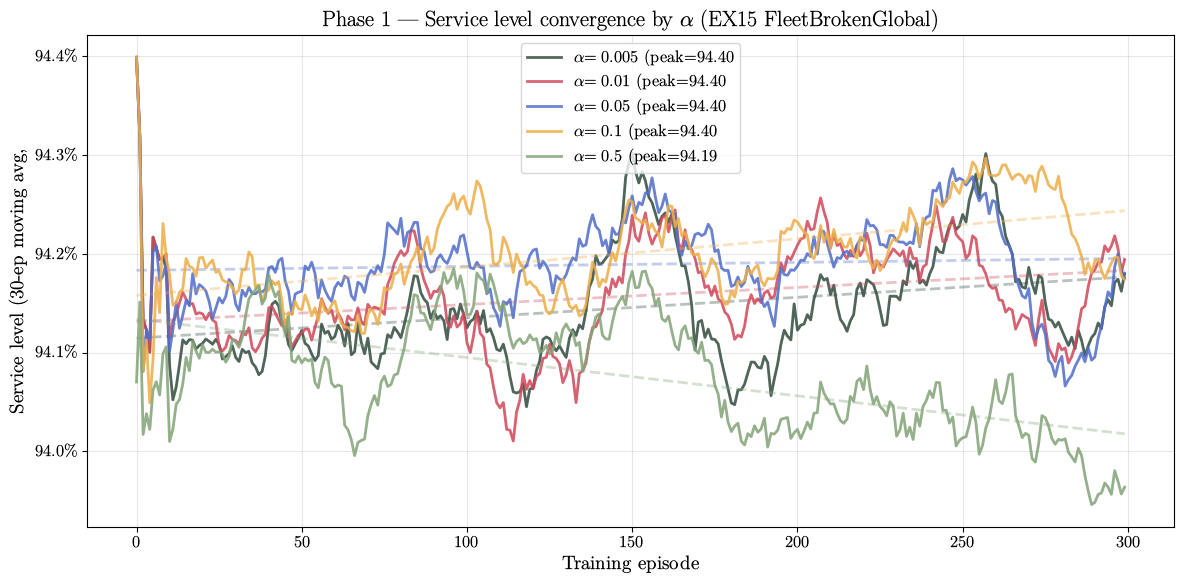

In [5]:
# ── Phase 1: SL convergence — plot options ───────────────────────────────
TITLE    = r"Phase 1 --- Service level convergence by $\alpha$ (EX15 FleetBrokenGlobal)"
SAVE_FIG = False  # save to hyperparameter_tuning_plots/
# ─────────────────────────────────────────────────────────────────────────
fig = plot_sl_comparison(
    groups_alpha, title=TITLE, param_label=r"$\alpha$", last_n=PHASE1_LAST_N,
)
if SAVE_FIG and fig:
        _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
        _PLOT_DIR.mkdir(exist_ok=True)
        fig.savefig(_PLOT_DIR / "phase1_sl_convergence.svg", bbox_inches="tight", dpi=150)
        print(f"Saved {_PLOT_DIR / 'phase1_sl_convergence.svg'}")
plt.show()

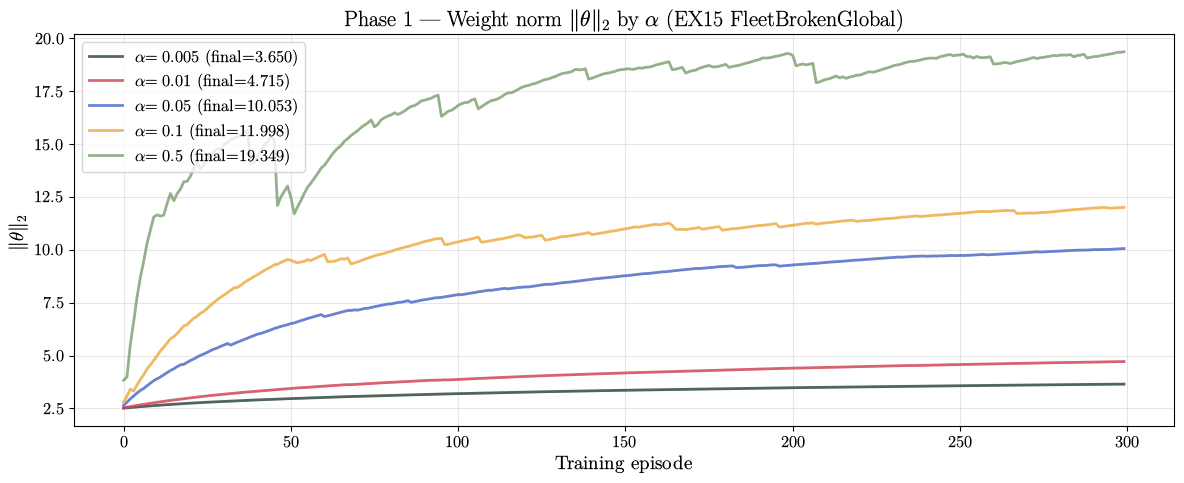

In [6]:
# ── Phase 1: Weight norm evolution — plot options ────────────────────────
TITLE    = r"Phase 1 --- Weight norm $\|\theta\|_2$ by $\alpha$ (EX15 FleetBrokenGlobal)"
SAVE_FIG = False
# ─────────────────────────────────────────────────────────────────────────
fig = plot_norm_evolution(groups_alpha, title=TITLE, param_label=r"$\alpha$")
if SAVE_FIG and fig:
        _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
        _PLOT_DIR.mkdir(exist_ok=True)
        fig.savefig(_PLOT_DIR / "phase1_norm_evolution.svg", bbox_inches="tight", dpi=150)
        print(f"Saved {_PLOT_DIR / 'phase1_norm_evolution.svg'}")
plt.show()

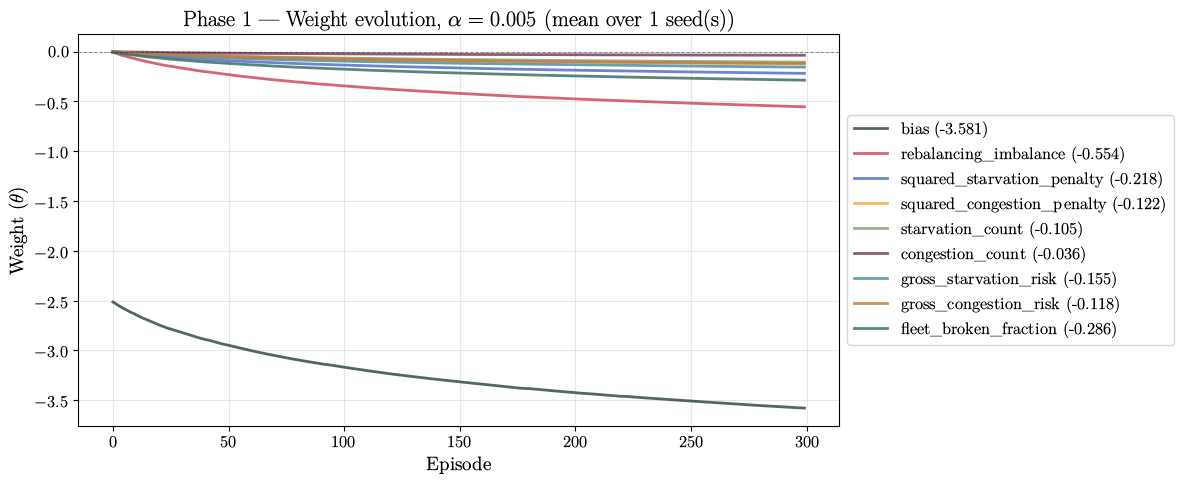

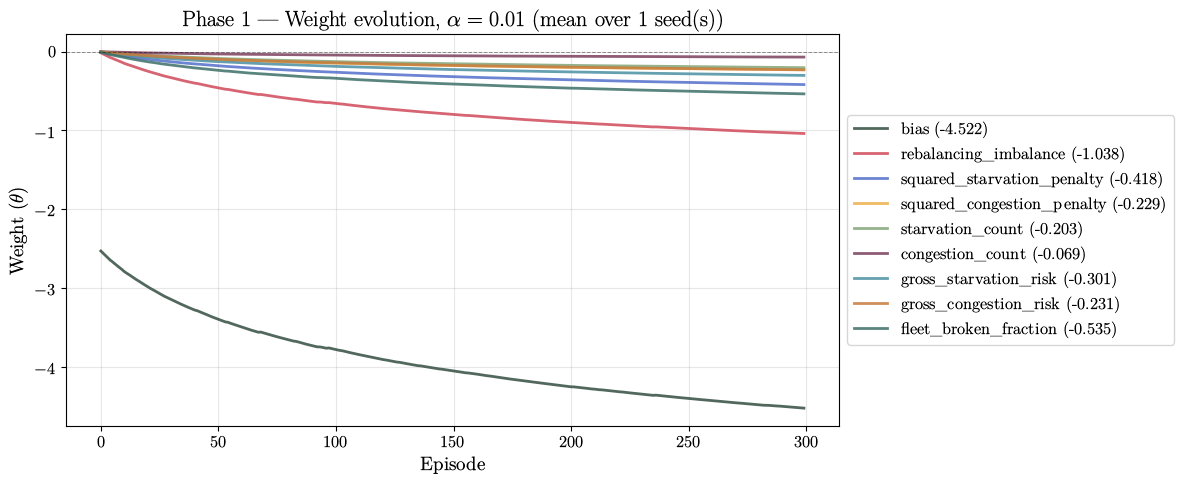

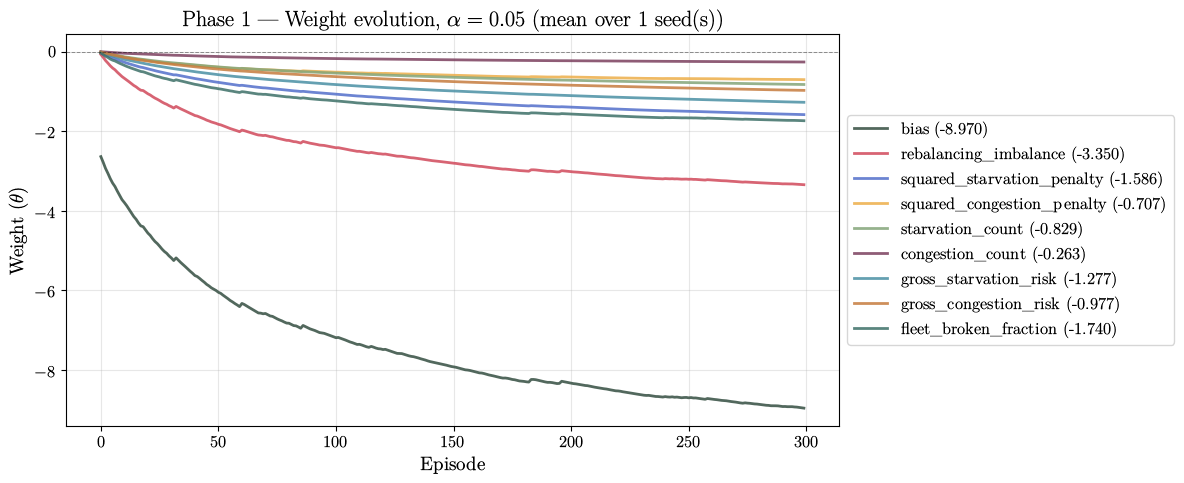

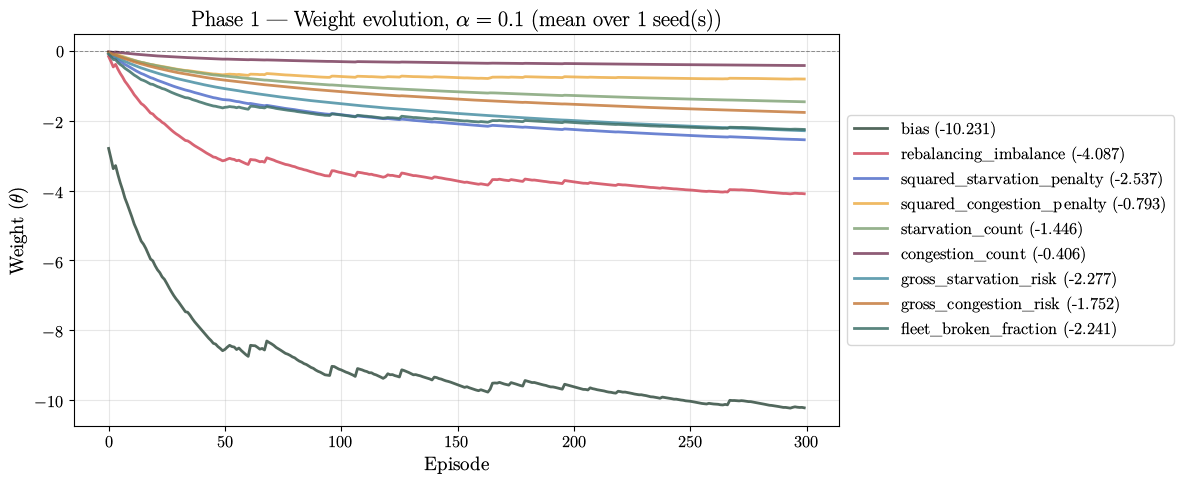

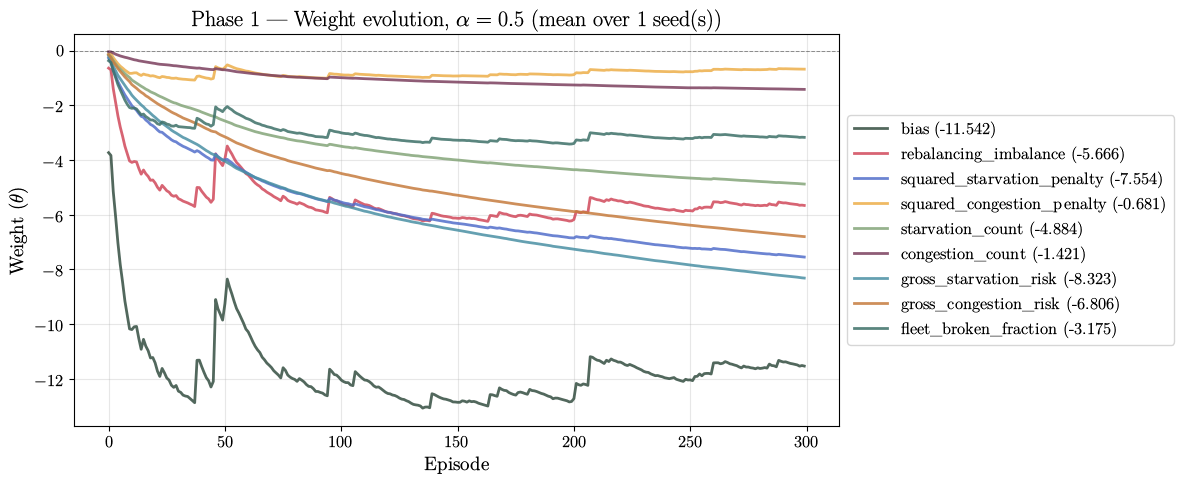

In [7]:
# ── Phase 1: Weight evolution per α — plot options ───────────────────────
TITLE_PREFIX = r"Phase 1 --- Weight evolution, $\alpha={v:g}$ (mean over {n} seed(s))"
SAVE_FIG     = False
# ─────────────────────────────────────────────────────────────────────────
for key in sorted(groups_alpha):
    runs = groups_alpha[key]
    try:
        v = float(key)
        title = TITLE_PREFIX.format(v=v, n=len(runs))
    except ValueError:
        title = f"Phase 1 \u2014 Weight evolution, \u03b1={key}"
    fig = plot_weight_evolution(runs, title=title)
    if fig:
        if SAVE_FIG:
            _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
            _PLOT_DIR.mkdir(exist_ok=True)
            fig.savefig(_PLOT_DIR / f"phase1_weight_evolution_{key}.svg", bbox_inches="tight", dpi=150)
        plt.show()

In [8]:
# ── Phase 1: Convergence metrics table ───────────────────────────────────
convergence_table(groups_alpha, param_name=r"$\alpha$", last_n=PHASE1_LAST_N)

<<<<<<< local


<<<<<<< local


<<<<<<< local <modified: text/html, text/plain>


,N seeds,Peak SL,Final SL (mean),"Final SL (std, seeds)",Convergence ep.,Final $\|\theta\|$
$\alpha$,,,,,,
0.005,1,0.9440,0.9414,0.0000,0,3.628
0.01,1,0.9440,0.9415,0.0000,0,4.676
0.05,1,0.9440,0.9412,0.0000,0,9.961
0.1,1,0.9440,0.9422,0.0000,0,11.878
0.5,1,0.9419,0.9399,0.0000,0,19.162


>>>>>>> remote


...

,N seeds,Peak SL,Final SL (mean),Convergence ep.,Final $\|\theta\|$,Rel. $\Delta\theta$ (%)
$\alpha$,,,,,,
0.005,1,94.40%,94.14%,0,3.628,0.05
0.01,1,94.40%,94.15%,0,4.676,0.06
0.05,1,94.40%,94.12%,0,9.961,0.08
0.1,1,94.40%,94.22%,0,11.878,0.11
0.5,1,94.19%,93.99%,0,19.162,0.26


,N seeds,Peak SL,Final SL (mean),Convergence ep.,Final $\|\theta\|$,Rel. $\Delta\theta$ (%)
$\alpha$,,,,,,
0.005,1,94.40%,94.14%,0,3.628,0.05
0.01,1,94.40%,94.15%,0,4.676,0.06
0.05,1,94.40%,94.12%,0,9.961,0.08
0.1,1,94.40%,94.22%,0,11.878,0.11
0.5,1,94.19%,93.99%,0,19.162,0.26


>>>>>>> remote <modified: text/html, text/plain>


>>>>>>> remote <modified: text/html, text/plain>


>>>>>>> remote <modified: text/html, text/plain>


In [9]:
# ── Phase 1: Lock α ──────────────────────────────────────────────────────
LOCKED_ALPHA = 0.1  # ← SET THIS after reviewing results above
print(f"Locked:  \u03b1 = {LOCKED_ALPHA}")

Locked:  α = 0.1


---
## Phase 2 — Discount Factor γ

**Before running this section**, train with the locked α:

```bash
python policies/sjovik_sund/ablation_study/run_ablation_study.py \
  --experiments EX15_FleetBrokenGlobal \
  --alphas 0.1 \
  --gammas 0.95 0.97 0.99 \
  --seeds 1000 \
  --episodes 300 \
  --output_dir tuning/phase2_gamma \
  --weight_starvation -1.0 \
  --weight_congestion -1.0 \
  --weight_fleet_degradation 0.0 \
  --use_bias_feature \
  --initial_bias -2.5 \
  --transition_update_interval 100 \
  --use_terminal_update \
  --use_feature_scale_diagnostics \
  --diagnostic_every_n_episodes 25 \
  --epsilon_start 0.0 \
  --epsilon_end 0.0
```

In [10]:
# ── Phase 2 config ────────────────────────────────────────────────────────
PHASE2_DIR    = "models/tuning/phase2_gamma"
PHASE2_LAST_N = 30

groups_gamma = load_training_runs(PHASE2_DIR, group_by="gamma", smooth_window=30)
print(f"Found {len(groups_gamma)} gamma group(s):")
for k, v in sorted(groups_gamma.items()):
    try:
        gval = _token_to_float(k)
        print(f"  \u03b3={gval:g}: {len(v)} seed(s)")
    except Exception:
        print(f"  key={k}: {len(v)} seed(s)")

Found 6 gamma group(s):
  γ=0.8: 1 seed(s)
  γ=0.85: 1 seed(s)
  γ=0.9: 1 seed(s)
  γ=0.95: 1 seed(s)
  γ=0.97: 1 seed(s)
  γ=0.99: 1 seed(s)


<<<<<<< local


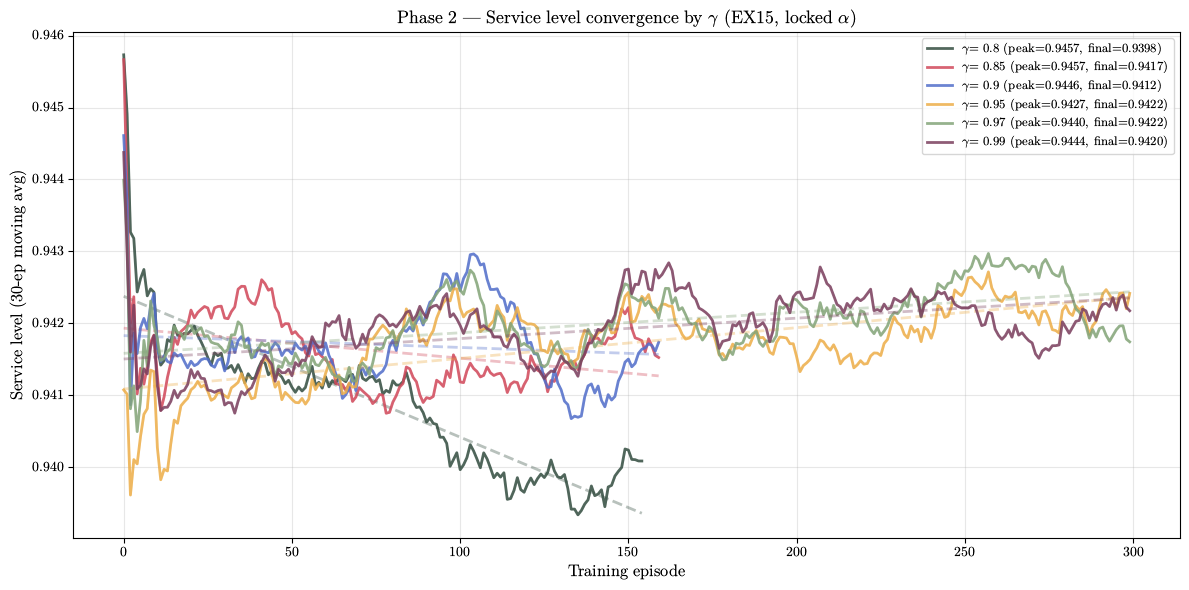

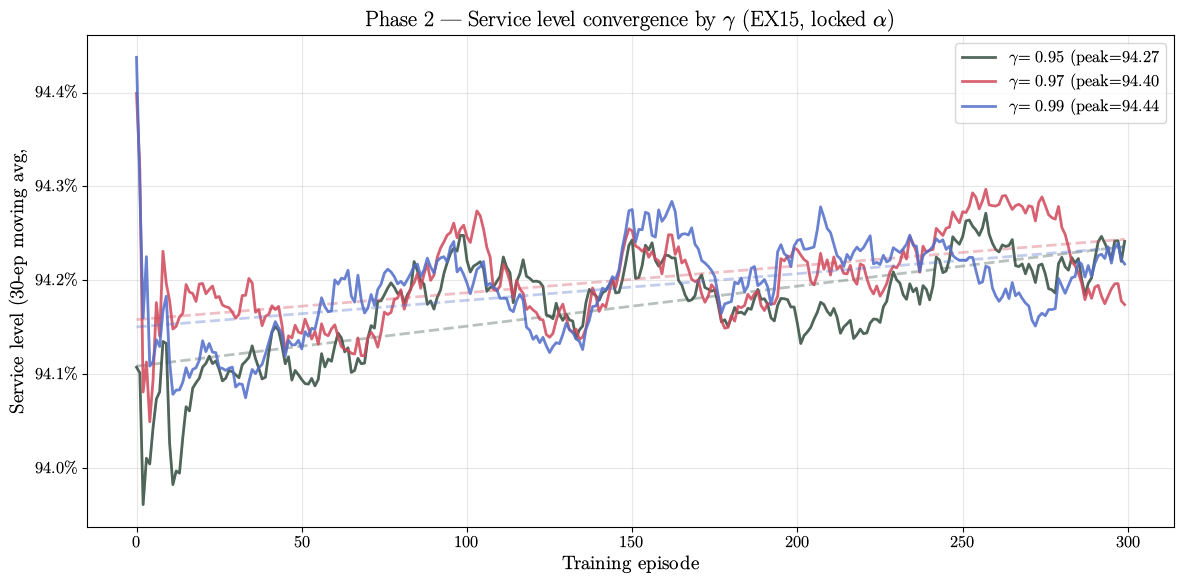

>>>>>>> remote


In [11]:
# ── Phase 2: SL convergence — plot options ───────────────────────────────
TITLE    = r"Phase 2 --- Service level convergence by $\gamma$ (EX15, locked $\alpha$)"
SAVE_FIG = False
# ─────────────────────────────────────────────────────────────────────────
fig = plot_sl_comparison(
    groups_gamma, title=TITLE, param_label=r"$\gamma$", last_n=PHASE2_LAST_N,
)
if SAVE_FIG and fig:
        _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
        _PLOT_DIR.mkdir(exist_ok=True)
        fig.savefig(_PLOT_DIR / "phase2_sl_convergence.svg", bbox_inches="tight", dpi=150)
        print(f"Saved {_PLOT_DIR / 'phase2_sl_convergence.svg'}")
plt.show()

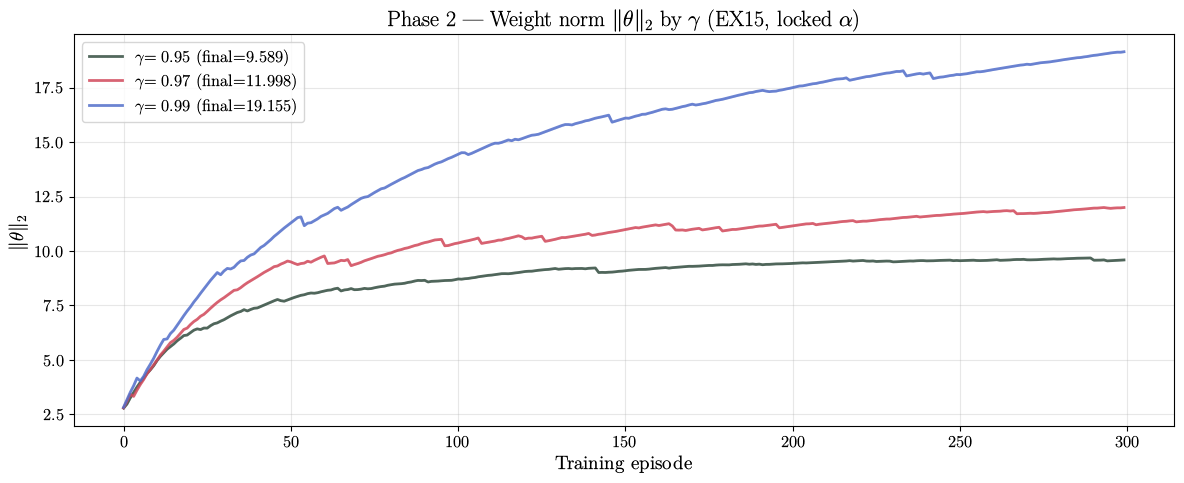

In [12]:
# ── Phase 2: Weight norm evolution — plot options ────────────────────────
TITLE    = r"Phase 2 --- Weight norm $\|\theta\|_2$ by $\gamma$ (EX15, locked $\alpha$)"
SAVE_FIG = False
# ─────────────────────────────────────────────────────────────────────────
fig = plot_norm_evolution(groups_gamma, title=TITLE, param_label=r"$\gamma$")
if SAVE_FIG and fig:
        _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
        _PLOT_DIR.mkdir(exist_ok=True)
        fig.savefig(_PLOT_DIR / "phase2_norm_evolution.svg", bbox_inches="tight", dpi=150)
        print(f"Saved {_PLOT_DIR / 'phase2_norm_evolution.svg'}")
plt.show()

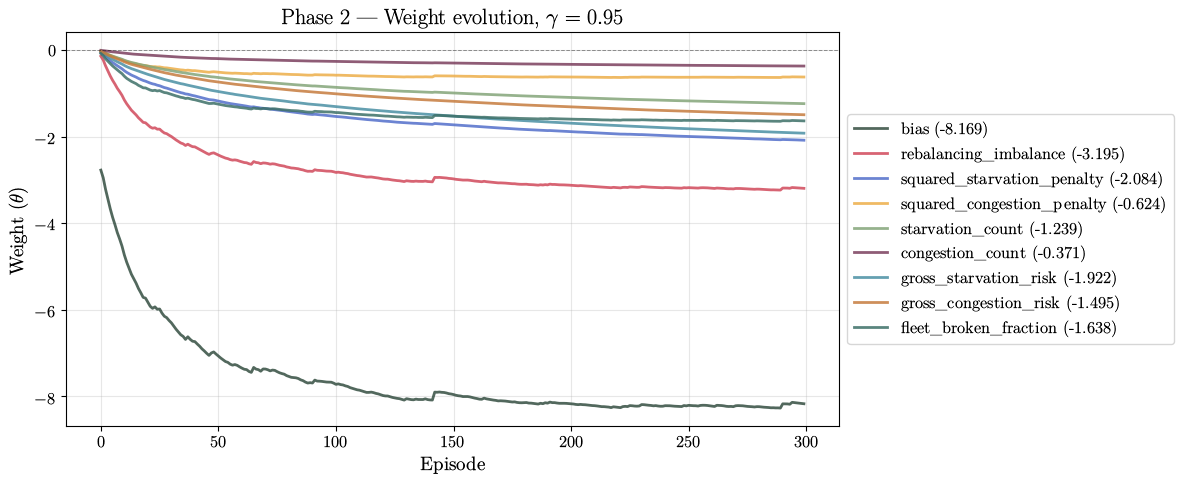

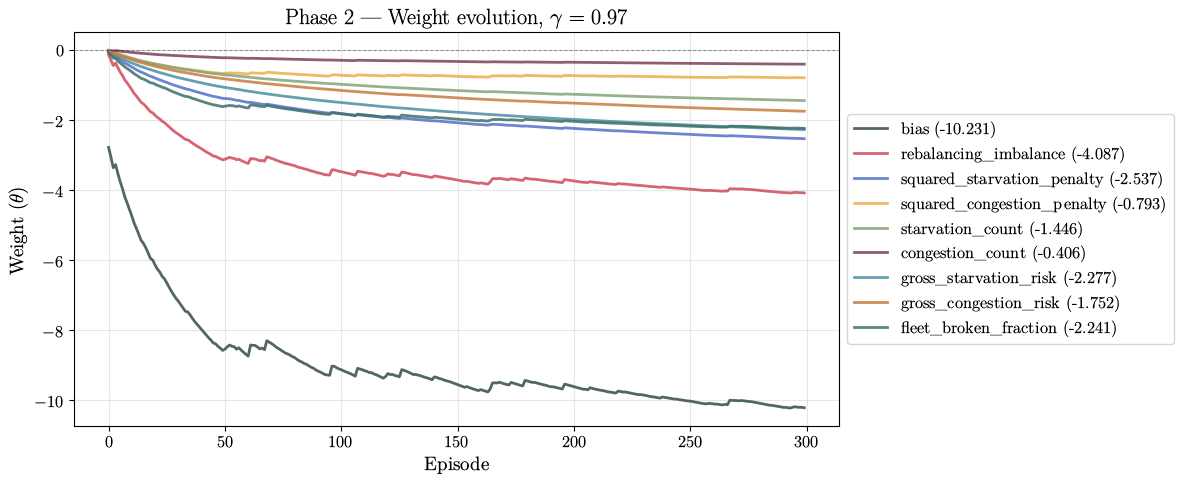

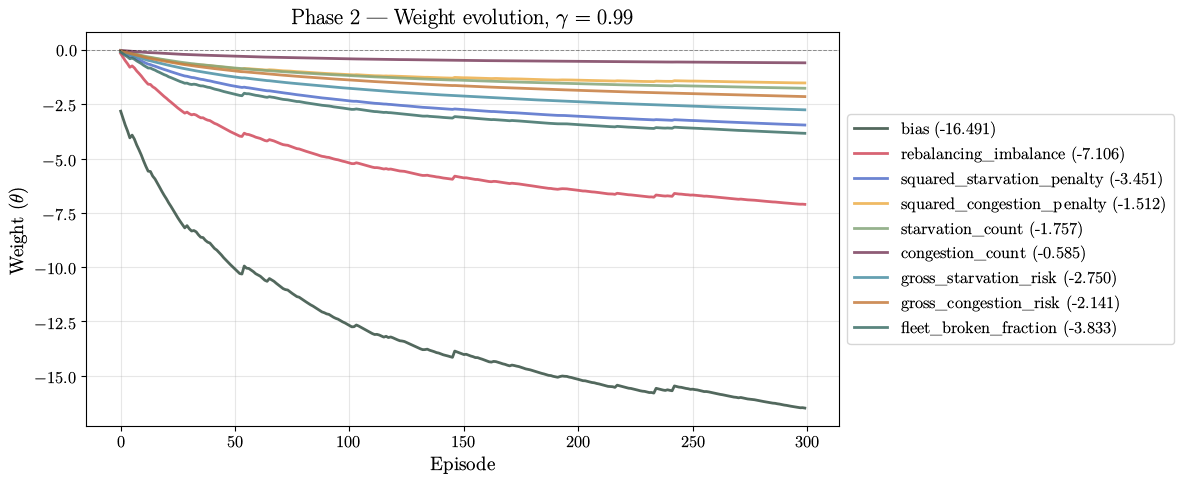

In [13]:
# ── Phase 2: Weight evolution per γ — plot options ───────────────────────
TITLE_PREFIX = r"Phase 2 --- Weight evolution, $\gamma={v:g}$"
SAVE_FIG     = False
# ─────────────────────────────────────────────────────────────────────────
for key in sorted(groups_gamma):
    runs = groups_gamma[key]
    try:
        v = _token_to_float(key)
        title = TITLE_PREFIX.format(v=v)
    except Exception:
        title = f"Phase 2 \u2014 Weight evolution, \u03b3={key}"
    fig = plot_weight_evolution(runs, title=title)
    if fig:
        if SAVE_FIG:
            _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
            _PLOT_DIR.mkdir(exist_ok=True)
            fig.savefig(_PLOT_DIR / f"phase2_weight_evolution_{key}.svg", bbox_inches="tight", dpi=150)
        plt.show()

In [14]:
# ── Phase 2: Convergence table ────────────────────────────────────────────
convergence_table(groups_gamma, param_name=r"$\gamma$", last_n=PHASE2_LAST_N)

<<<<<<< local


<<<<<<< local


<<<<<<< local <modified: text/html, text/plain>


,N seeds,Peak SL,Final SL (mean),"Final SL (std, seeds)",Convergence ep.,Final $\|\theta\|$
$\gamma$,,,,,,
0p8,1,0.9457,0.9398,0.0000,0,3.339
0p85,1,0.9457,0.9417,0.0000,0,4.308
0p9,1,0.9446,0.9412,0.0000,0,5.775
0p95,1,0.9427,0.9422,0.0000,0,9.616
0p97,1,0.9440,0.9422,0.0000,0,11.878
0p99,1,0.9444,0.9420,0.0000,0,18.866


>>>>>>> remote


...

,N seeds,Peak SL,Final SL (mean),Convergence ep.,Final $\|\theta\|$,Rel. $\Delta\theta$ (%)
$\gamma$,,,,,,
0p95,1,94.27%,94.22%,0,9.616,0.12
0p97,1,94.40%,94.22%,0,11.878,0.11
0p99,1,94.44%,94.20%,0,18.866,0.11


,N seeds,Peak SL,Final SL (mean),Convergence ep.,Final $\|\theta\|$,Rel. $\Delta\theta$ (%)
$\gamma$,,,,,,
0p95,1,94.27%,94.22%,0,9.616,0.12
0p97,1,94.40%,94.22%,0,11.878,0.11
0p99,1,94.44%,94.20%,0,18.866,0.11


>>>>>>> remote <modified: text/html, text/plain>


>>>>>>> remote <modified: text/html, text/plain>


>>>>>>> remote <modified: text/html, text/plain>


In [15]:
# ── Phase 2: Lock γ ───────────────────────────────────────────────────────
LOCKED_GAMMA = 0.97   # ← SET THIS after reviewing results above
print(f"Locked:  \u03b3 = {LOCKED_GAMMA}")

Locked:  γ = 0.97


Saved /Users/ingvildvs/FOMOsim/policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots/final_sl_convergence.svg


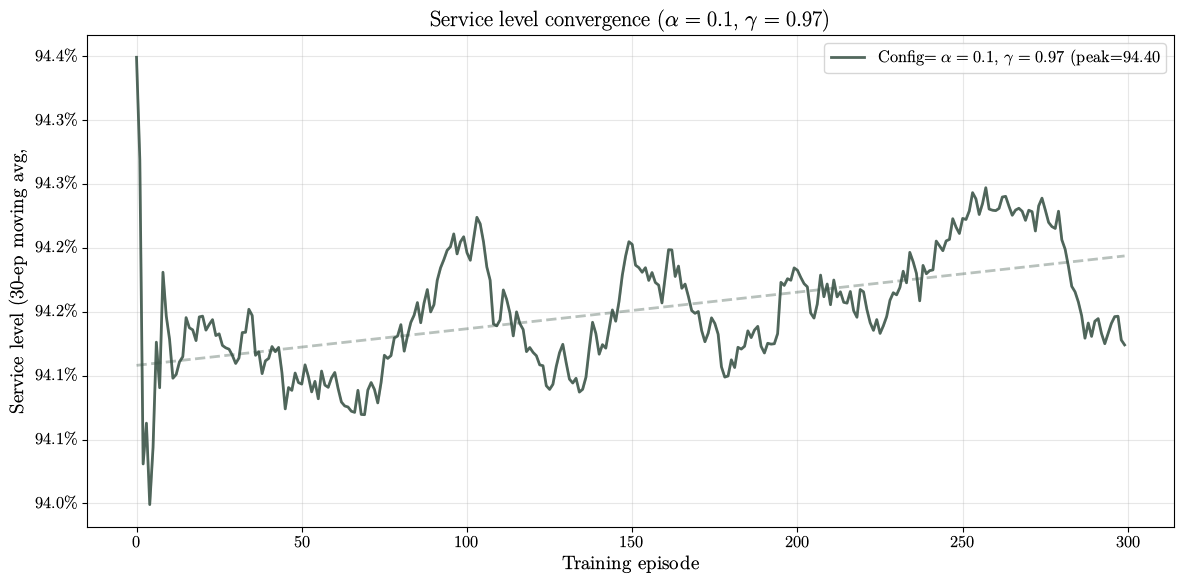

Saved /Users/ingvildvs/FOMOsim/policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots/final_weight_evolution.svg


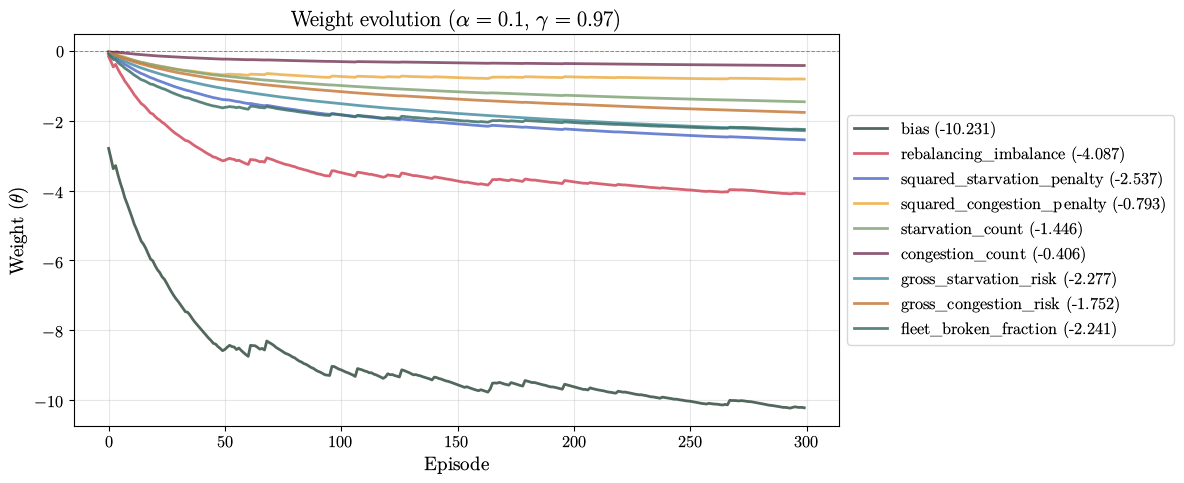

In [16]:
#Plot final convergence comparison with locked α and γ
# ── Plot options ─────────────────────────────────────────────────────────
TITLE_SL = (r"Service level convergence"
            rf" ($\alpha={LOCKED_ALPHA:g}$, $\gamma={LOCKED_GAMMA:g}$)")
TITLE_W  = (r"Weight evolution"
            rf" ($\alpha={LOCKED_ALPHA:g}$, $\gamma={LOCKED_GAMMA:g}$)")
SAVE_FIG = True
# ─────────────────────────────────────────────────────────────────────────

# Locate the groups_gamma entry whose float value matches LOCKED_GAMMA
_locked_key = next(
    (k for k in groups_gamma if abs(_token_to_float(k) - LOCKED_GAMMA) < 1e-6),
    None,
)
if _locked_key is None:
    print(f"WARNING: γ={LOCKED_GAMMA} not found in groups_gamma.")
    print(f"  Available keys: {list(groups_gamma)}")
else:
    _locked_runs   = groups_gamma[_locked_key]
    _locked_groups = {rf"\alpha={LOCKED_ALPHA:g},\, \gamma={LOCKED_GAMMA:g}": _locked_runs}
    _plot_dir = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"

    # ── SL convergence ────────────────────────────────────────────────────
    fig = plot_sl_comparison(
        _locked_groups,
        title=TITLE_SL,
        param_label="Config",
        last_n=PHASE2_LAST_N,
    )
    if SAVE_FIG and fig:
        _plot_dir.mkdir(exist_ok=True)
        fig.savefig(_plot_dir / "final_sl_convergence.svg", bbox_inches="tight", dpi=150)
        print(f"Saved {_plot_dir / 'final_sl_convergence.svg'}")
    plt.show()

    # ── Weight evolution ──────────────────────────────────────────────────
    fig = plot_weight_evolution(_locked_runs, title=TITLE_W)
    if SAVE_FIG and fig:
        _plot_dir.mkdir(exist_ok=True)
        fig.savefig(_plot_dir / "final_weight_evolution.svg", bbox_inches="tight", dpi=150)
        print(f"Saved {_plot_dir / 'final_weight_evolution.svg'}")
    plt.show()


---
## Phase 3 — Reward Weights (ws, wc)

Run three separate training jobs (one per variant), then evaluate each with
`run_simulation_ingvild.py --policy hybrid`.

```bash
# Variant A: equal weights (baseline)
python policies/sjovik_sund/ablation_study/run_ablation_study.py \
  --experiments EX15_FleetBrokenGlobal \
  --alphas 0.1 \
  --gammas 0.97 \
  --weight_starvation -1.0 \
  --weight_congestion -1.0 \
  --weight_fleet_degradation 0.0 \
  --seeds 1000 \
  --episodes 300 \
  --output_dir tuning/phase3_reward \
  --use_bias_feature \
  --initial_bias -2.5 \
  --transition_update_interval 100 \
  --use_terminal_update \
  --use_feature_scale_diagnostics \
  --diagnostic_every_n_episodes 25 \
  --epsilon_start 0.0 \
  --epsilon_end 0.0

# Variant B: starvation-downweighted  (change --weight_starvation -0.7)
# Variant C: congestion-downweighted  (change --weight_congestion -0.7)
```

Then evaluate each trained model:

```bash
python policies/sjovik_sund/run_simulation_ingvild.py \
  --policy hybrid --vfa-model <PKL_PATH> \
  --lookahead 60 --num-scenarios 5 --n-routing 5\
  --warmup-days 7 --duration 504 --nsims 10 --seed 42 \
  --log-files results daily decisions hourly
```

Point `PHASE3_RUN_LOGS` to the resulting run log folders below.

In [17]:
# ── Phase 3 config ────────────────────────────────────────────────────────
# Map run_log path → display label for each reward variant
PHASE3_RUN_LOGS = {
    "run_logs/tuning/phase3_ws-1.0_wc-1.0": r"ws=$-1.0$, wc=$-1.0$",
    "run_logs/tuning/phase3_ws-0.7_wc-1.0": r"ws=$-0.7$, wc=$-1.0$",
    "run_logs/tuning/phase3_ws-1.0_wc-0.7": r"ws=$-1.0$, wc=$-0.7$",
}
PHASE3_METRICS = ["service_level", "starvations", "congestions", "functional_ratio_end"]

df3 = load_eval_results(list(PHASE3_RUN_LOGS.keys()), label_override=PHASE3_RUN_LOGS)
print(f"Loaded {len(df3)} seed rows from {df3['label'].nunique() if not df3.empty else 0} variants")
if not df3.empty:
    for lbl, grp in df3.groupby("label"):
        n_total = len(grp)
        n_unique = grp["seed"].nunique() if "seed" in grp.columns else n_total
        dup_note = f"  *** {n_total - n_unique} duplicate seed rows" if n_total != n_unique else ""
        print(f"  {lbl!r}: N={n_total} rows, {n_unique} unique seeds{dup_note}")
    display(df3[["label", "seed", "service_level", "starvations", "congestions"]].head(12))
else:
    print("No data yet.")

Loaded 30 seed rows from 3 variants
  'ws=$-0.7$, wc=$-1.0$': N=10 rows, 10 unique seeds
  'ws=$-1.0$, wc=$-0.7$': N=10 rows, 10 unique seeds
  'ws=$-1.0$, wc=$-1.0$': N=10 rows, 10 unique seeds


,label,seed,service_level,starvations,congestions
0,"ws=$-1.0$, wc=$-1.0$",42,0.9494,2138,911
1,"ws=$-1.0$, wc=$-1.0$",43,0.9506,2084,886
2,"ws=$-1.0$, wc=$-1.0$",44,0.9470,2235,912
3,"ws=$-1.0$, wc=$-1.0$",45,0.9471,2274,874
4,"ws=$-1.0$, wc=$-1.0$",46,0.9524,1952,854
5,"ws=$-1.0$, wc=$-1.0$",47,0.9510,1979,933
6,"ws=$-1.0$, wc=$-1.0$",48,0.9478,2275,836
7,"ws=$-1.0$, wc=$-1.0$",49,0.9523,1967,854
8,"ws=$-1.0$, wc=$-1.0$",50,0.9499,2162,815
9,"ws=$-1.0$, wc=$-1.0$",51,0.9505,2113,848


<<<<<<< local


<<<<<<< local


<<<<<<< local <modified: text/html, text/plain>


,Service level (mean),Service level (std),Starvations (mean),Starvations (std),Congestions (mean),Congestions (std),Func. ratio end (FR) (mean),Func. ratio end (FR) (std)
Label,,,,,,,,
"ws=$-1.0$, wc=$-1.0$ (equal)",0.9498,0.0020,2117.9,122.9,872.3,37.7,0.9719,0.0087


>>>>>>> remote


...

,N,Service level (%) (mean),Service level (%) (std),Starvations (mean),Starvations (std),Congestions (mean),Congestions (std),Func. ratio end (FR) (mean),Func. ratio end (FR) (std)
Label,,,,,,,,,
"ws=$-0.7$, wc=$-1.0$",10,95.03%,0.22%,2159.6,128.8,801.9,50.7,97.53%,0.68%
"ws=$-1.0$, wc=$-1.0$",10,94.98%,0.20%,2117.9,122.9,872.3,37.7,97.19%,0.87%
"ws=$-1.0$, wc=$-0.7$",10,94.96%,0.26%,2122.0,189.6,881.9,71.7,97.13%,0.58%


>>>>>>> remote <modified: text/html, text/plain>


>>>>>>> remote <modified: text/html, text/plain>


<<<<<<< local


>>>>>>> remote <modified: text/html, text/plain>


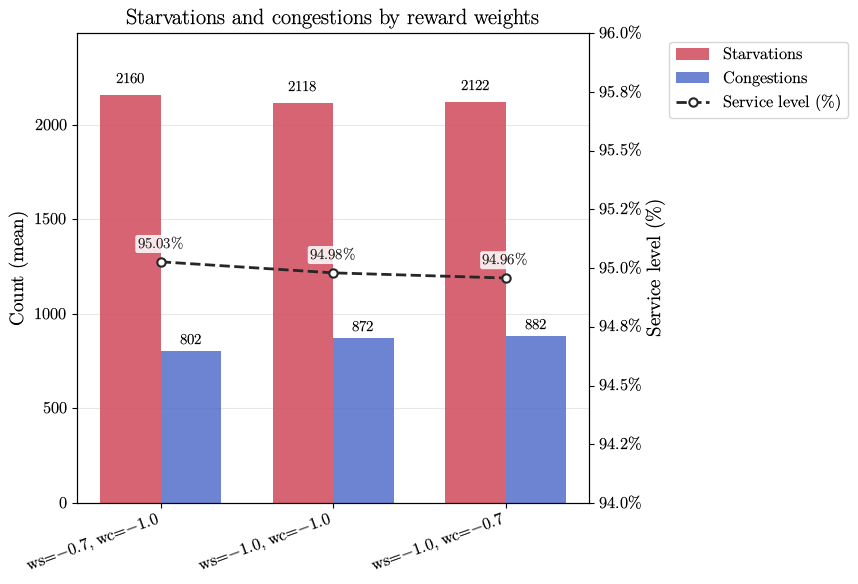

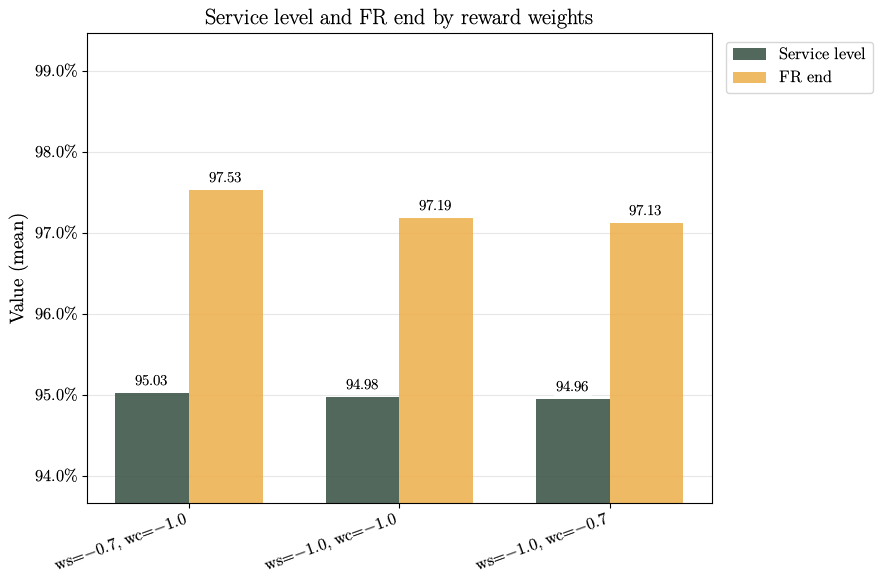

>>>>>>> remote


<<<<<<< local <unchanged>


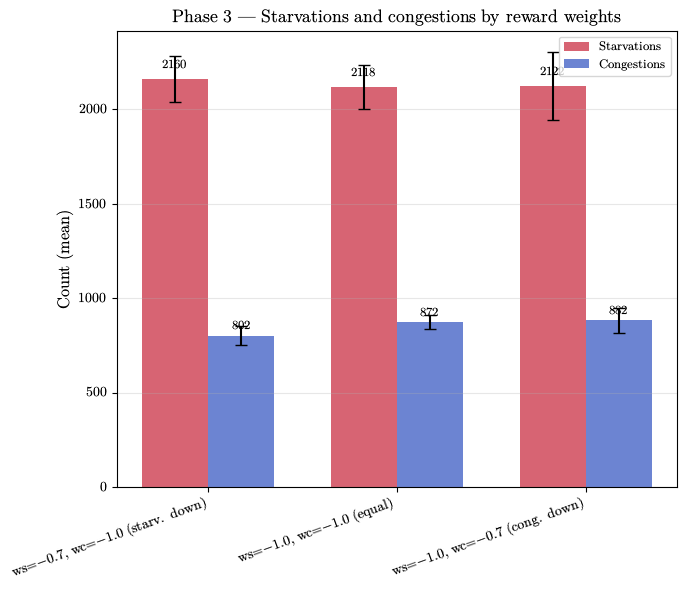

>>>>>>> remote <removed>


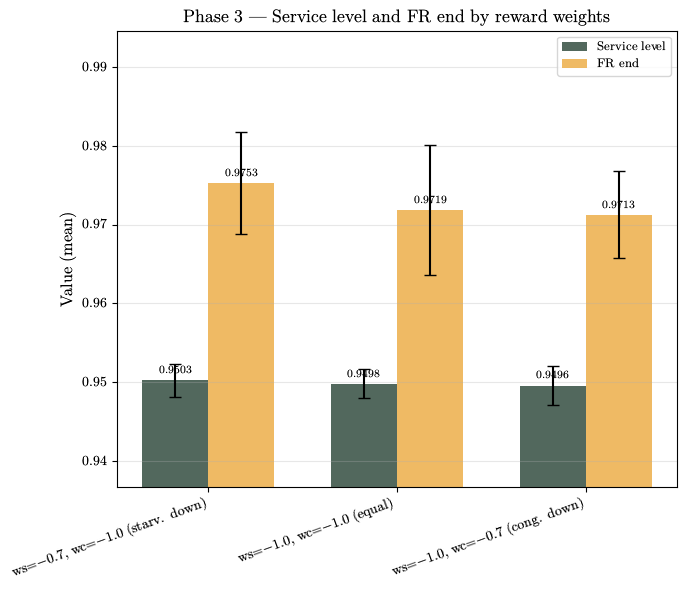

In [18]:
# ── Phase 3: Bar charts — plot options ───────────────────────────────────
TITLE_SC   = "Starvations and congestions by reward weights" #
TITLE_SL   = "Service level and FR end by reward weights"
XLABEL     = None      # None = no x-axis label
YLABEL_SC  = None      # None = "Count (mean)"
YLABEL_SL  = None      # None = "Value (mean)"
SHOW_VALS  = True      # show values on top of bars
SHOW_ERR   = False         # show std error bars
SHOW_SL    = True          # overlay service level line on starvation/congestion chart
SL_YLIM    = (0.94, 0.96)  # right-axis range for service level
SAVE_FIG   = True         # save to hyperparameter_tuning_plots/
# ─────────────────────────────────────────────────────────────────────────
if not df3.empty:
    display(eval_summary_table(df3, PHASE3_METRICS, sort_by="service_level"))

    fig = plot_starv_cong_grouped(df3, title=TITLE_SC, xlabel=XLABEL, ylabel=YLABEL_SC,
                                   show_labels=SHOW_VALS, show_errorbars=SHOW_ERR,
                                   show_service_level=SHOW_SL, service_level_ylim=SL_YLIM)
    if SAVE_FIG and fig:
        _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
        _PLOT_DIR.mkdir(exist_ok=True)
        fig.savefig(_PLOT_DIR / "phase3_starv_cong.svg", bbox_inches="tight", dpi=150)
    plt.show()

    fig = plot_sl_fr_grouped(df3, title=TITLE_SL, xlabel=XLABEL, ylabel=YLABEL_SL,
                              show_labels=SHOW_VALS, show_errorbars=SHOW_ERR)
    if SAVE_FIG and fig:
        fig.savefig(_PLOT_DIR / "phase3_sl_fr.svg", bbox_inches="tight", dpi=150)
    plt.show()
else:
    print("No data loaded yet \u2014 populate PHASE3_RUN_LOGS and re-run.")

In [19]:
# -- Phase 3: Load decisions data for hourly profile --
df3_dec = load_decisions_data(list(PHASE3_RUN_LOGS.keys()), label_override=PHASE3_RUN_LOGS)
print(f"Decisions rows: {len(df3_dec)} "
      f"from {df3_dec['label'].nunique() if not df3_dec.empty else 0} experiment(s)")


Decisions rows: 48166 from 3 experiment(s)


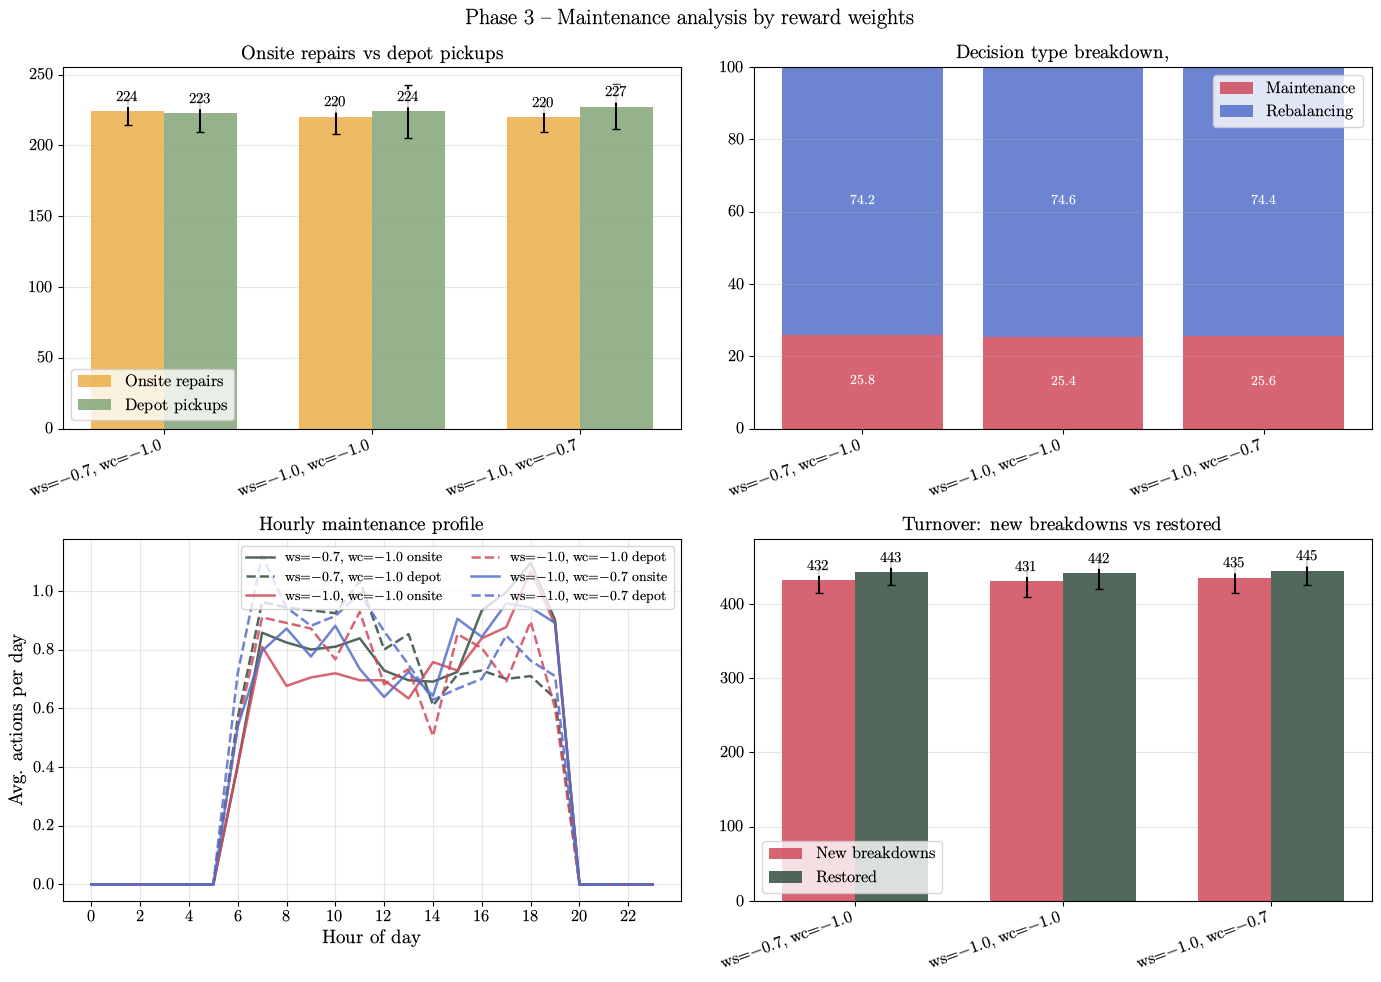

In [20]:
# ── Phase 3: Maintenance grid — plot options ─────────────────────────────
TITLE     = "Phase 3 -- Maintenance analysis by reward weights"
SHOW_VALS = True    # show values on top of bars
SHOW_ERR  = True    # show std error bars
SAVE_FIG  = False
# ─────────────────────────────────────────────────────────────────────────
if not df3.empty:
    fig = plot_maintenance_grid(
        df3,
        df3_dec if not df3_dec.empty else None,
        title=TITLE,
        show_labels=SHOW_VALS,
        show_errorbars=SHOW_ERR,
    )
    if SAVE_FIG and fig:
        _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
        _PLOT_DIR.mkdir(exist_ok=True)
        fig.savefig(_PLOT_DIR / "phase3_maintenance_grid.svg", bbox_inches="tight", dpi=150)
    plt.show()
else:
    print("No data loaded yet.")

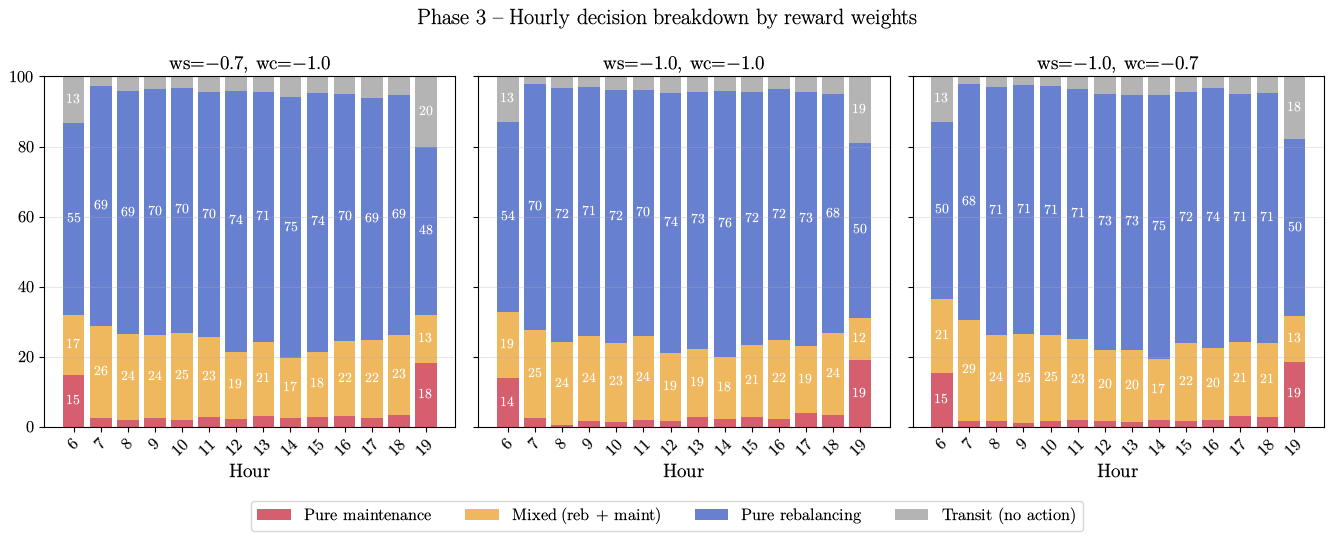

In [21]:
# ── Phase 3: Hourly breakdown — plot options ─────────────────────────────
TITLE     = "Phase 3 -- Hourly decision breakdown by reward weights"
SHOW_VALS = True    # show % labels inside stacked bars
SAVE_FIG  = False
# ─────────────────────────────────────────────────────────────────────────
if not df3_dec.empty:
    fig = plot_hourly_decision_breakdown(
        df3_dec,
        df_results=df3,
        title=TITLE,
        show_labels=SHOW_VALS,
    )
    if SAVE_FIG and fig:
        _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
        _PLOT_DIR.mkdir(exist_ok=True)
        fig.savefig(_PLOT_DIR / "phase3_hourly_breakdown.svg", bbox_inches="tight", dpi=150)
    plt.show()
else:
    print("No decisions data loaded yet.")

In [22]:
# ── Phase 3: Lock reward weights ──────────────────────────────────────────
LOCKED_WS = -1.0   # ← weight_starvation
LOCKED_WC = -1.0   # ← weight_congestion
print(f"Locked:  ws = {LOCKED_WS},  wc = {LOCKED_WC}")

Locked:  ws = -1.0,  wc = -1.0


---
## Phase 4 — Rollout Parameters

Coordinate-descent evaluation with the locked VFA — no retraining.

**Step 1 — H × S grid**: jointly evaluate all combinations of lookahead horizon
H ∈ {30, 60, 90, 120} min and scenario count S ∈ {3, 5, 10, 20} with R = 5 fixed.
Set `--n-time-steps = H / 5` to keep 5-minute sub-intervals (30→6, 60→12, 90→18, 120→24).

**Step 2 — R × S grid**: fix the lookahead horizon at H = 90 min and jointly evaluate
routing candidates R ∈ {1, 3, 5, 10} and scenario count S ∈ {3, 5, 10, 20}.

Results are reported as **SL (%) / failed events / functional bike ratio end / mean decision runtime (s)**.

```bash
# Run once per (H, S) combination — adjust --lookahead, --n-time-steps, --num-scenarios
python policies/sjovik_sund/run_simulation_ingvild.py \
  --policy hybrid \
  --vfa-model <PATH_TO_LOCKED_VFA_PKL> \
  --active-features bias rebalancing_imbalance squared_starvation_penalty squared_congestion_penalty starvation_count congestion_count gross_starvation_risk gross_congestion_risk fleet_broken_fraction \
  --weight-starvation -1.0 --weight-congestion -1.0 \
  --lookahead <H> --n-time-steps <H//5> --num-scenarios <S> --n-routing 5 \
  --warmup-days 7 --duration 504 \
  --nsims 10 --seed 42 \
  --log-files results daily decisions hourly
```


In [23]:
# ── Phase 4 config ────────────────────────────────────────────────────────
PHASE4_H_VALUES = [30, 60, 90, 120]
PHASE4_S_VALUES = [3, 5, 10, 20]
R_FIXED = 5

# Map (H, S) → run_log directory containing seed_*/results.csv and seed_*/decisions.csv
# Fill in each path after the corresponding run completes.
PHASE4_GRID_LOGS = {
    (30,   3): "run_logs/tuning/phase4_SLgrid/H30_S3",
    (30,   5): "run_logs/tuning/phase4_SLgrid/H30_S5",
    (30,  10): "run_logs/tuning/phase4_SLgrid/H30_S10",
    (30,  20): "run_logs/tuning/phase4_SLgrid/H30_S20",
    (60,   3): "run_logs/tuning/phase4_SLgrid/H60_S3",
    (60,   5): "run_logs/tuning/phase4_SLgrid/H60_S5",
    (60,  10): "run_logs/tuning/phase4_SLgrid/H60_S10",
    (60,  20): "run_logs/tuning/phase4_SLgrid/H60_S20",
    (90,   3): "run_logs/tuning/phase4_SLgrid/H90_S3",
    (90,   5): "run_logs/tuning/phase4_SLgrid/H90_S5",
    (90,  10): "run_logs/tuning/phase4_SLgrid/H90_S10",
    (90,  20): "run_logs/tuning/phase4_SLgrid/H90_S20",
    (120,  3): "run_logs/tuning/phase4_SLgrid/H120_S3",
    (120,  5): "run_logs/tuning/phase4_SLgrid/H120_S5",
    (120, 10): "run_logs/tuning/phase4_SLgrid/H120_S10",
    (120, 20): "run_logs/tuning/phase4_SLgrid/H120_S20",
}

# Step 2: R × S grid with H fixed at the selected lookahead horizon.
# Dedicated phase4_routing logs are preferred; R=5 can fall back to the Step 1 H=90 grid.
PHASE4_ROUTING_LOOKAHEAD = 90
PHASE4_ROUTING_S_VALUES = [3, 5, 10, 20]
PHASE4_R_VALUES = [1, 3, 5, 10]

def _first_existing_log_path(*paths: str) -> str | None:
    for path in paths:
        if path is not None and Path(path).exists() and any(Path(path).rglob("results.csv")):
            return path
    for path in paths:
        if path is not None and Path(path).exists():
            return path
    return paths[0] if paths else None


PHASE4_ROUTING_LOGS = {
    (r, s): f"run_logs/tuning/phase4_routing_H90_RAfix/R{r}_S{s}"
    for r in PHASE4_R_VALUES
    for s in PHASE4_ROUTING_S_VALUES
}

# Preview how many cells have data
def _has_results(path: str | None) -> bool:
    return path is not None and Path(path).exists() and any(Path(path).rglob("results.csv"))


grid_filled = sum(_has_results(v) for v in PHASE4_GRID_LOGS.values())
routing_filled = sum(_has_results(v) for v in PHASE4_ROUTING_LOGS.values())
print(f"Step 1 grid cells populated: {grid_filled} / {len(PHASE4_GRID_LOGS)}")
print(f"Step 2 routing cells populated: {routing_filled} / {len(PHASE4_ROUTING_LOGS)}")


Step 1 grid cells populated: 0 / 16
Step 2 routing cells populated: 0 / 16


In [24]:
# ── Phase 4 Step 1: H × S grid table ─────────────────────────────────────
def _mean_functional_ratio_end(df: pd.DataFrame) -> float:
    """Mean functional bike ratio at the end of the run."""
    if "functional_ratio_end" in df.columns:
        return float(df["functional_ratio_end"].mean())
    onsite = "broken_ratio_end_onsite"
    depot = "broken_ratio_end_depot"
    if onsite in df.columns and depot in df.columns:
        return float((1.0 - df[onsite] - df[depot]).mean())
    if "broken_ratio_end" in df.columns:
        return float((1.0 - df["broken_ratio_end"]).mean())
    return float("nan")


def _mean_failed_events(df: pd.DataFrame) -> float:
    """Mean failed demand events: starvations + congestions."""
    if {"starvations", "congestions"}.issubset(df.columns):
        return float((df["starvations"] + df["congestions"]).mean())
    return float("nan")


def _dedupe_seed_rows(df: pd.DataFrame, path) -> pd.DataFrame:
    """Combine split run folders without double-counting repeated seeds."""
    if df.empty or "seed" not in df.columns:
        return df
    df = df.copy()
    df["_seed_key"] = pd.to_numeric(df["seed"], errors="coerce")
    if "source" in df.columns:
        def _source_mtime(src):
            try:
                return (WORKSPACE_ROOT / src).stat().st_mtime
            except Exception:
                return -1.0
        df["_source_mtime"] = df["source"].map(_source_mtime)
        df = df.sort_values(["_seed_key", "_source_mtime", "source"])
        drop_cols = ["_seed_key", "_source_mtime"]
    else:
        df = df.sort_values(["_seed_key"])
        drop_cols = ["_seed_key"]
    before = len(df)
    df = df.drop_duplicates(subset=["_seed_key"], keep="last")
    dropped = before - len(df)
    if dropped:
        print(f"Deduplicated {dropped} duplicate seed row(s) at {path}")
    return df.drop(columns=drop_cols)


def _load_cell(path):
    """Return (mean_sl, mean_failed_events, mean_fr_end, mean_rt) for one path."""
    if path is None:
        return None, None, None, None
    df = load_eval_results([path])
    if df.empty:
        return None, None, None, None
    df = _dedupe_seed_rows(df, path)
    sl = float(df["service_level"].mean())
    failed_events = _mean_failed_events(df)
    fr_end = _mean_functional_ratio_end(df)
    rt = (float(df["avg_decision_runtime_s"].mean())
          if "avg_decision_runtime_s" in df.columns else float("nan"))
    return sl, failed_events, fr_end, rt


def phase4_grid_table(grid_logs, h_values, s_values):
    """H × S pivot: cells show SL (%) / failed events / FR end / runtime."""
    rows = []
    for h in h_values:
        row = {"$H$ (min)": h}
        for s in s_values:
            sl, failed_events, fr_end, rt = _load_cell(grid_logs.get((h, s)))
            row[f"$S={s}$"] = f"{sl*100:.2f}% / {failed_events:.0f} / {fr_end:.4f} / {rt:.2f}" if sl is not None else "—"
        rows.append(row)
    return pd.DataFrame(rows).set_index("$H$ (min)")


grid_df = phase4_grid_table(PHASE4_GRID_LOGS, PHASE4_H_VALUES, PHASE4_S_VALUES)
display(
    grid_df.style
    .set_caption(f"Phase 4 Step 1 — SL (%) / failed events / functional bike ratio end / mean decision runtime (s)  [R={R_FIXED} fixed]")
)


,$S=3$,$S=5$,$S=10$,$S=20$
$H$ (min),,,,
30,94.77% / 3117 / 0.9722 / 0.66,94.92% / 3026 / 0.9731 / 1.09,95.03% / 2960 / 0.9726 / 2.06,95.04% / 2953 / 0.9723 / 4.19
60,94.94% / 3013 / 0.9694 / 0.71,94.98% / 2990 / 0.9719 / 1.15,95.09% / 2922 / 0.9681 / 2.20,95.23% / 2840 / 0.9739 / 4.47
90,94.94% / 3012 / 0.9692 / 0.73,95.05% / 2949 / 0.9710 / 1.18,95.11% / 2914 / 0.9729 / 2.27,95.16% / 2884 / 0.9758 / 4.45
120,94.94% / 3016 / 0.9698 / 0.76,95.01% / 2975 / 0.9720 / 1.18,95.14% / 2895 / 0.9720 / 2.37,95.22% / 2849 / 0.9717 / 4.60


In [25]:
# ── Phase 4 Step 2: R × S routing/scenario grid table ─────────────────────
def phase4_routing_grid_table(routing_logs, r_values, s_values):
    """R × S pivot: cells show SL (%) / failed events / FR end / runtime."""
    rows = []
    for r in r_values:
        row = {"$R$": r}
        for s in s_values:
            sl, failed_events, fr_end, rt = _load_cell(routing_logs.get((r, s)))
            row[f"$S={s}$"] = f"{sl*100:.2f}% / {failed_events:.0f} / {fr_end:.4f} / {rt:.2f}" if sl is not None else "—"
        rows.append(row)
    return pd.DataFrame(rows).set_index("$R$")


routing_grid_df = phase4_routing_grid_table(
    PHASE4_ROUTING_LOGS,
    PHASE4_R_VALUES,
    PHASE4_ROUTING_S_VALUES,
)

display(
    routing_grid_df.style
    .set_caption(
        f"Phase 4 Step 2 — SL (%) / failed events / functional bike ratio end / "
        f"mean decision runtime (s)  [H={PHASE4_ROUTING_LOOKAHEAD} min fixed]"
    )
)


Deduplicated 1 duplicate seed row(s) at run_logs/tuning/phase4_routing_H90_RAfix/R10_S20


,$S=3$,$S=5$,$S=10$,$S=20$
$R$,,,,
1,94.89% / 3043 / 0.9722 / 0.23,94.88% / 3050 / 0.9727 / 0.37,94.76% / 3124 / 0.9743 / 0.66,94.74% / 3130 / 0.9741 / 1.24
3,94.91% / 3036 / 0.9719 / 0.49,95.05% / 2950 / 0.9694 / 0.73,95.19% / 2865 / 0.9711 / 1.42,95.18% / 2872 / 0.9745 / 2.81
5,94.94% / 3012 / 0.9692 / 0.72,95.05% / 2949 / 0.9710 / 1.14,95.11% / 2914 / 0.9729 / 2.30,95.16% / 2884 / 0.9758 / 4.45
10,94.80% / 3096 / 0.9724 / 1.34,94.91% / 3032 / 0.9686 / 2.24,95.06% / 2941 / 0.9733 / 4.47,95.18% / 2870 / 0.9696 / 8.65


Deduplicated 1 duplicate seed row(s) at run_logs/tuning/phase4_routing_H90_RAfix/R10_S20
Saved phase4_sl_lineplots.svg


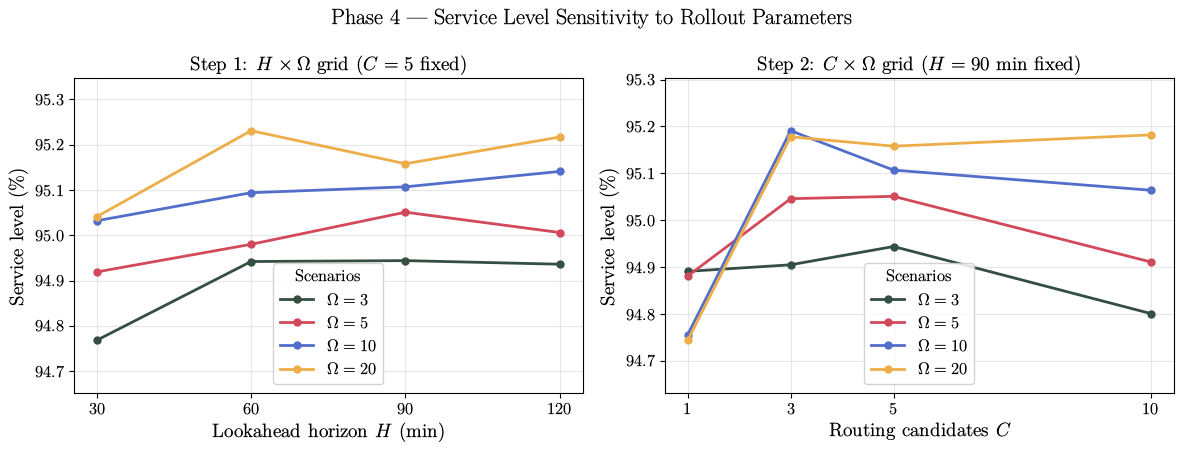

In [26]:
# ── Phase 4: Service level line plots ─────────────────────────────────────
SAVE_FIG = True


def _phase4_sl_lines(ax, x_values, line_values, logs, key_fn,
                     x_label: str, title: str):
    """Plot mean service level by one rollout parameter, grouped by scenarios."""
    all_sl = []
    for i, omega in enumerate(line_values):
        xs, ys = [], []
        for x in x_values:
            sl, _failed_events, _fr_end, _rt = _load_cell(logs.get(key_fn(x, omega)))
            xs.append(x)
            ys.append(sl * 100 if sl is not None else np.nan)
        y_arr = np.array(ys, dtype=float)
        if np.all(np.isnan(y_arr)):
            continue
        all_sl.extend(y_arr[np.isfinite(y_arr)].tolist())
        ax.plot(
            xs, y_arr,
            marker="o", linewidth=2.0, markersize=5,
            color=COLORS[i % len(COLORS)],
            label=rf"$\Omega={omega}$",
        )

    ax.set_xlabel(x_label, fontsize=AXIS_FONTSIZE)
    ax.set_ylabel(r"Service level (\%)", fontsize=AXIS_FONTSIZE)
    ax.set_title(title, fontsize=AXIS_FONTSIZE)
    ax.set_xticks(x_values)
    ax.grid(True, alpha=0.3)
    ax.legend(title=r"Scenarios", fontsize=LEGEND_FONTSIZE, framealpha=0.85)

    if all_sl:
        lo, hi = min(all_sl), max(all_sl)
        pad = max((hi - lo) * 0.25, 0.08)
        ax.set_ylim(lo - pad, hi + pad)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=False)
fig.suptitle(
    r"Phase 4 --- Service Level Sensitivity to Rollout Parameters",
    fontsize=TITLE_FONTSIZE,
)

_phase4_sl_lines(
    axes[0],
    PHASE4_H_VALUES,
    PHASE4_S_VALUES,
    PHASE4_GRID_LOGS,
    lambda h, omega: (h, omega),
    r"Lookahead horizon $H$ (min)",
    r"Step 1: $H \times \Omega$ grid ($C=5$ fixed)",
)

_phase4_sl_lines(
    axes[1],
    PHASE4_R_VALUES,
    PHASE4_ROUTING_S_VALUES,
    PHASE4_ROUTING_LOGS,
    lambda c, omega: (c, omega),
    r"Routing candidates $C$",
    r"Step 2: $C \times \Omega$ grid ($H=90$ min fixed)",
)

fig.tight_layout()

if SAVE_FIG:
    _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
    _PLOT_DIR.mkdir(exist_ok=True)
    fig.savefig(_PLOT_DIR / "phase4_sl_lineplots.svg", bbox_inches="tight", dpi=PLOT_DPI)
    print("Saved phase4_sl_lineplots.svg")

plt.show()


Deduplicated 1 duplicate seed row(s) at run_logs/tuning/phase4_routing_H90_RAfix/R10_S20
Saved phase4_cxomega_sl_grid.svg


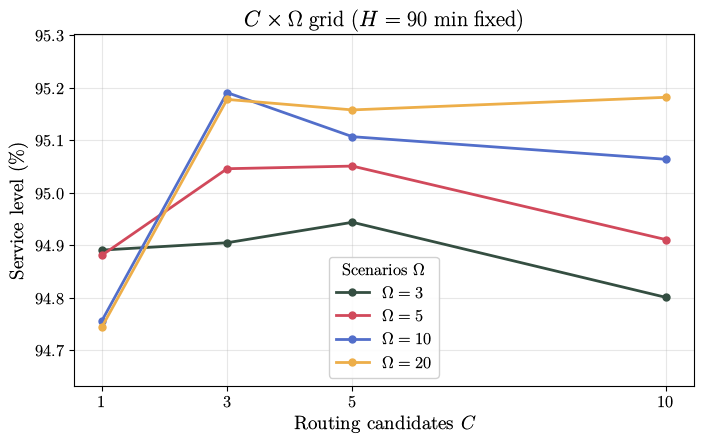

In [27]:
# ── Phase 4 Step 2: C × Ω service-level grid only ─────────────────────────
SAVE_FIG = True

fig, ax = plt.subplots(figsize=(7.2, 4.6))
all_sl = []

for i, omega in enumerate(PHASE4_ROUTING_S_VALUES):
    xs, ys = [], []
    for c in PHASE4_R_VALUES:
        sl, _failed_events, _fr_end, _rt = _load_cell(PHASE4_ROUTING_LOGS.get((c, omega)))
        xs.append(c)
        ys.append(sl * 100 if sl is not None else np.nan)
    y_arr = np.array(ys, dtype=float)
    if np.all(np.isnan(y_arr)):
        continue
    all_sl.extend(y_arr[np.isfinite(y_arr)].tolist())
    ax.plot(
        xs,
        y_arr,
        marker="o",
        linewidth=2.0,
        markersize=5,
        color=COLORS[i % len(COLORS)],
        label=rf"$\Omega={omega}$",
    )

ax.set_title(
    rf"$C \times \Omega$ grid ($H={PHASE4_ROUTING_LOOKAHEAD}$ min fixed)",
    fontsize=TITLE_FONTSIZE,
)
ax.set_xlabel(r"Routing candidates $C$", fontsize=AXIS_FONTSIZE)
ax.set_ylabel(r"Service level (\%)", fontsize=AXIS_FONTSIZE)
ax.set_xticks(PHASE4_R_VALUES)
ax.grid(True, alpha=0.3)
ax.legend(title=r"Scenarios $\Omega$", fontsize=LEGEND_FONTSIZE, framealpha=0.9)

if all_sl:
    lo, hi = min(all_sl), max(all_sl)
    pad = max((hi - lo) * 0.25, 0.08)
    ax.set_ylim(lo - pad, hi + pad)

fig.tight_layout()

if SAVE_FIG:
    _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
    _PLOT_DIR.mkdir(exist_ok=True)
    fig.savefig(_PLOT_DIR / "phase4_cxomega_sl_grid.svg", bbox_inches="tight", dpi=PLOT_DPI)
    print("Saved phase4_cxomega_sl_grid.svg")

plt.show()


Deduplicated 1 duplicate seed row(s) at run_logs/tuning/phase4_routing_H90_RAfix/R10_S20
Saved phase4_heatmaps.svg


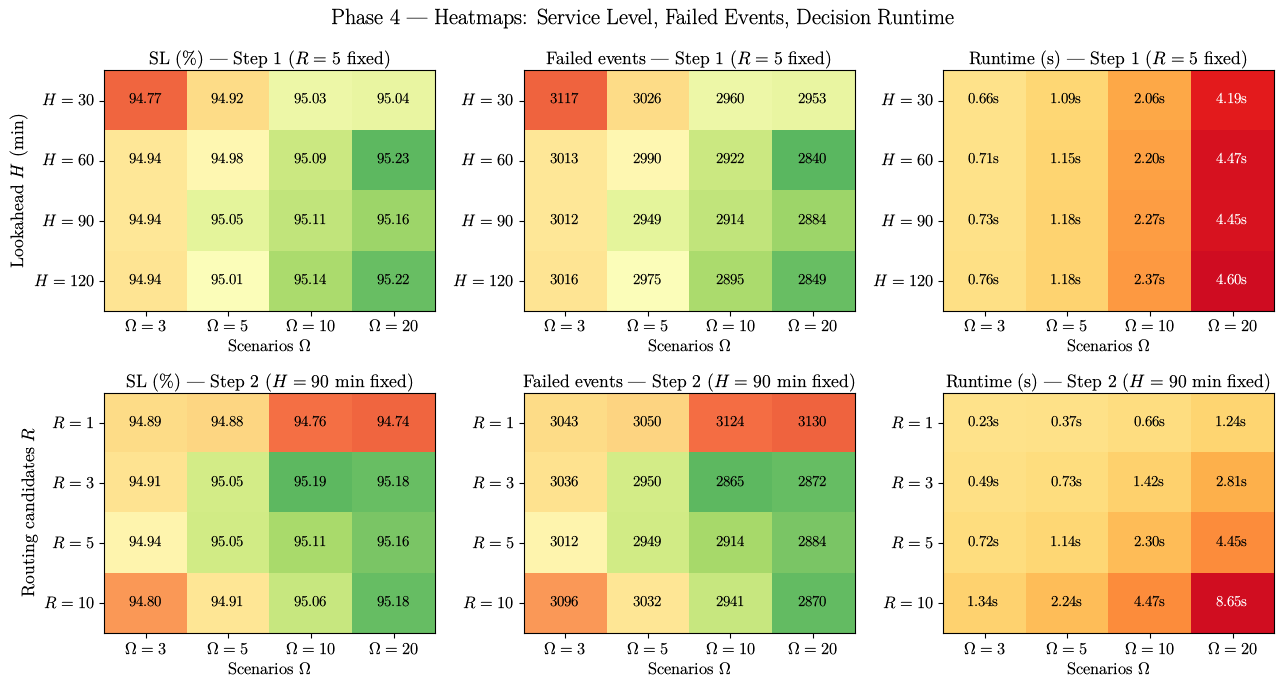

In [28]:
# ── Phase 4: Heatmaps ─────────────────────────────────────────────────────
import matplotlib.colors as mcolors

SAVE_FIG = True


def _build_numeric_arrays(key_map, row_keys, col_keys):
    n_r, n_c = len(row_keys), len(col_keys)
    sl_arr = np.full((n_r, n_c), np.nan)
    fe_arr = np.full((n_r, n_c), np.nan)
    rt_arr = np.full((n_r, n_c), np.nan)
    for i, rk in enumerate(row_keys):
        for j, ck in enumerate(col_keys):
            path = key_map.get((rk, ck))
            if path:
                _sl, _fe, _fr, _rt = _load_cell(path)
                if _sl is not None:
                    sl_arr[i, j] = _sl * 100
                    fe_arr[i, j] = _fe
                    rt_arr[i, j] = _rt
    return sl_arr, fe_arr, rt_arr


step1_sl, step1_fe, step1_rt = _build_numeric_arrays(
    PHASE4_GRID_LOGS, PHASE4_H_VALUES, PHASE4_S_VALUES
)
step2_sl, step2_fe, step2_rt = _build_numeric_arrays(
    PHASE4_ROUTING_LOGS, PHASE4_R_VALUES, PHASE4_ROUTING_S_VALUES
)


def _draw_heatmap(ax, data, row_labels, col_labels, fmt, cmap, title="",
                  vmin=None, vmax=None):
    _vmin = vmin if vmin is not None else np.nanmin(data)
    _vmax = vmax if vmax is not None else np.nanmax(data)
    if vmin is None and vmax is None:
        _pad = 0.3 * (_vmax - _vmin)
        _vmin -= _pad
        _vmax += _pad
    im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=_vmin, vmax=_vmax)
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, fontsize=AXIS_FONTSIZE - 2)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=AXIS_FONTSIZE - 2)
    ax.set_title(title, fontsize=AXIS_FONTSIZE - 1, pad=4)
    norm = mcolors.Normalize(vmin=_vmin, vmax=_vmax)
    cmap_obj = plt.get_cmap(cmap)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.isnan(val):
                ax.text(j, i, "---", ha="center", va="center", fontsize=HEATMAP_FONTSIZE)
                continue
            bg = cmap_obj(norm(val))
            lum = 0.299 * bg[0] + 0.587 * bg[1] + 0.114 * bg[2]
            ax.text(j, i, fmt(val), ha="center", va="center",
                    fontsize=HEATMAP_FONTSIZE, color="white" if lum < 0.5 else "black")
    return im


s_labels = [rf"$\Omega={s}$" for s in PHASE4_S_VALUES]
h_labels = [f"$H={h}$" for h in PHASE4_H_VALUES]
r_labels = [f"$R={r}$" for r in PHASE4_R_VALUES]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.suptitle(
    r"Phase 4 --- Heatmaps: Service Level, Failed Events, Decision Runtime",
    fontsize=TITLE_FONTSIZE,
)

_draw_heatmap(axes[0, 0], step1_sl, h_labels, s_labels,
              lambda v: f"{v:.2f}%", "RdYlGn",
              title=r"SL (\%) --- Step 1 ($R=5$ fixed)")
_draw_heatmap(axes[0, 1], step1_fe, h_labels, s_labels,
              lambda v: f"{v:.0f}", "RdYlGn_r",
              title=r"Failed events --- Step 1 ($R=5$ fixed)")
_draw_heatmap(axes[0, 2], step1_rt, h_labels, s_labels,
              lambda v: f"{v:.2f}s", "YlOrRd",
              title=r"Runtime (s) --- Step 1 ($R=5$ fixed)")

_draw_heatmap(axes[1, 0], step2_sl, r_labels, s_labels,
              lambda v: f"{v:.2f}%", "RdYlGn",
              title=r"SL (\%) --- Step 2 ($H=90$ min fixed)")
_draw_heatmap(axes[1, 1], step2_fe, r_labels, s_labels,
              lambda v: f"{v:.0f}", "RdYlGn_r",
              title=r"Failed events --- Step 2 ($H=90$ min fixed)")
_draw_heatmap(axes[1, 2], step2_rt, r_labels, s_labels,
              lambda v: f"{v:.2f}s", "YlOrRd",
              title=r"Runtime (s) --- Step 2 ($H=90$ min fixed)")

for ax in axes.flat:
    ax.set_xlabel(r"Scenarios $\Omega$", fontsize=AXIS_FONTSIZE - 2)
axes[0, 0].set_ylabel(r"Lookahead $H$ (min)", fontsize=AXIS_FONTSIZE - 1)
axes[1, 0].set_ylabel(r"Routing candidates $R$", fontsize=AXIS_FONTSIZE - 1)

fig.tight_layout()

if SAVE_FIG:
    _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
    _PLOT_DIR.mkdir(exist_ok=True)
    fig.savefig(_PLOT_DIR / "phase4_heatmaps.svg", bbox_inches="tight", dpi=PLOT_DPI)
    print(f"Saved phase4_heatmaps.svg")

plt.show()


Saved phase4_pareto.svg


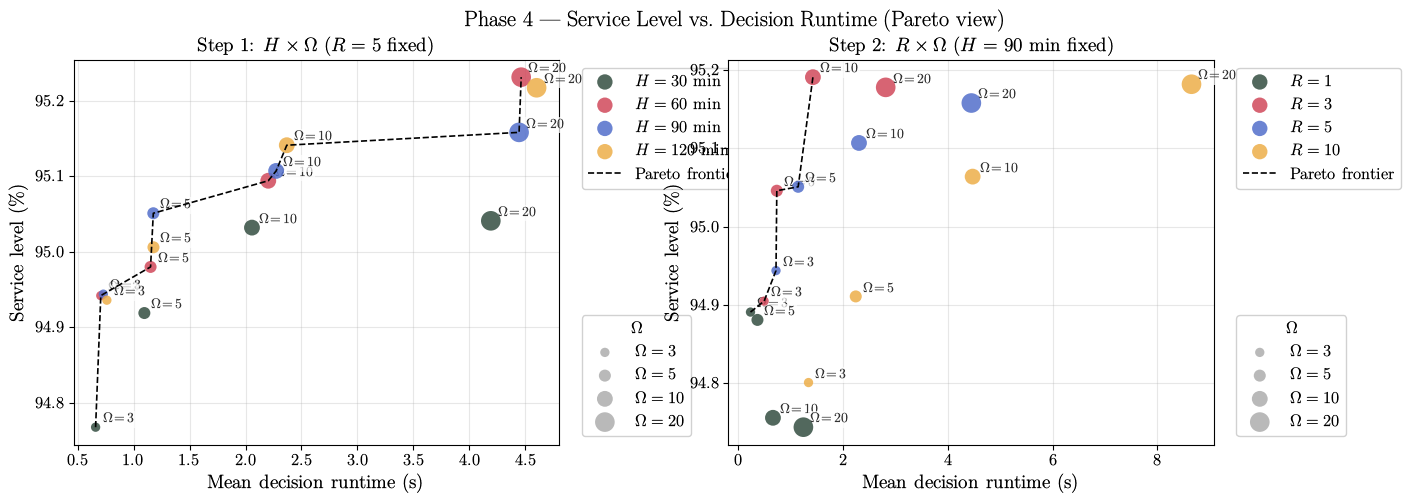

In [29]:
# ── Phase 4: Pareto scatter ───────────────────────────────────────────────
SAVE_FIG = True


def _pareto_mask(rts, sls):
    """True if point is not dominated (maximize SL, minimize runtime)."""
    rts, sls = np.asarray(rts, dtype=float), np.asarray(sls, dtype=float)
    mask = np.ones(len(rts), dtype=bool)
    for i in range(len(rts)):
        dominated = (
            (rts <= rts[i]) & (sls >= sls[i]) &
            ((rts < rts[i]) | (sls > sls[i]))
        )
        dominated[i] = False
        if dominated.any():
            mask[i] = False
    return mask


_s_sizes = {3: 45, 5: 75, 10: 130, 20: 200}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    r"Phase 4 --- Service Level vs.\ Decision Runtime (Pareto view)",
    fontsize=TITLE_FONTSIZE,
)

for ax, title, sl_arr, rt_arr, row_keys, s_keys, row_fmt in [
    (axes[0],
     r"Step 1: $H \times \Omega$ ($R=5$ fixed)",
     step1_sl, step1_rt,
     PHASE4_H_VALUES, PHASE4_S_VALUES, r"$H={v}$ min"),
    (axes[1],
     r"Step 2: $R \times \Omega$ ($H=90$ min fixed)",
     step2_sl, step2_rt,
     PHASE4_R_VALUES, PHASE4_ROUTING_S_VALUES, r"$R={v}$"),
]:
    all_rt, all_sl = [], []
    for i, rk in enumerate(row_keys):
        pts_x, pts_y, pts_sz = [], [], []
        for j, s in enumerate(s_keys):
            sl_v = sl_arr[i, j]
            rt_v = rt_arr[i, j]
            if not np.isnan(sl_v):
                pts_x.append(rt_v)
                pts_y.append(sl_v)
                pts_sz.append(_s_sizes.get(s, 80))
                all_rt.append(rt_v)
                all_sl.append(sl_v)
                ax.annotate(rf"$\Omega\!=\!{s}$", (rt_v, sl_v),
                            textcoords="offset points", xytext=(5, 3),
                            fontsize=SMALL_FONTSIZE, color="#333333",
                            bbox=dict(facecolor="white", alpha=0.7,
                                      edgecolor="none", pad=1.5))
        ax.scatter(pts_x, pts_y, color=COLORS[i], s=pts_sz,
                   label=row_fmt.format(v=rk), alpha=0.85,
                   edgecolors="none", zorder=3)

    rts_a = np.array(all_rt)
    sls_a = np.array(all_sl)
    mask = _pareto_mask(rts_a, sls_a)
    idx = np.argsort(rts_a[mask])
    ax.plot(rts_a[mask][idx], sls_a[mask][idx],
            color="black", lw=1.2, ls="--", zorder=4, label="Pareto frontier")
    size_handles = [ax.scatter([], [], s=_s_sizes[s], color="gray",
                               alpha=0.55, edgecolors="none")
                    for s in sorted(_s_sizes)]
    size_leg = ax.legend(size_handles, [rf"$\Omega={s}$" for s in sorted(_s_sizes)],
                         title=r"$\Omega$", fontsize=LEGEND_FONTSIZE,
                         framealpha=0.9, loc="lower left",
                         bbox_to_anchor=(1.03, 0.0), bbox_transform=ax.transAxes)
    ax.add_artist(size_leg)

    ax.set_xlabel(r"Mean decision runtime (s)", fontsize=AXIS_FONTSIZE)
    ax.set_ylabel(r"Service level (\%)", fontsize=AXIS_FONTSIZE)
    ax.set_title(title, fontsize=AXIS_FONTSIZE)
    ax.legend(fontsize=LEGEND_FONTSIZE, framealpha=0.9,
              loc="upper left", bbox_to_anchor=(1.03, 1.0),
              bbox_transform=ax.transAxes)
    ax.grid(True, alpha=0.3)

fig.subplots_adjust(left=0.06, right=0.82, wspace=0.35)

if SAVE_FIG:
    _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
    _PLOT_DIR.mkdir(exist_ok=True)
    fig.savefig(_PLOT_DIR / "phase4_pareto.svg", bbox_inches="tight", dpi=PLOT_DPI)
    print(f"Saved phase4_pareto.svg")

plt.show()


Saved phase4_step1_sl_heatmap.svg


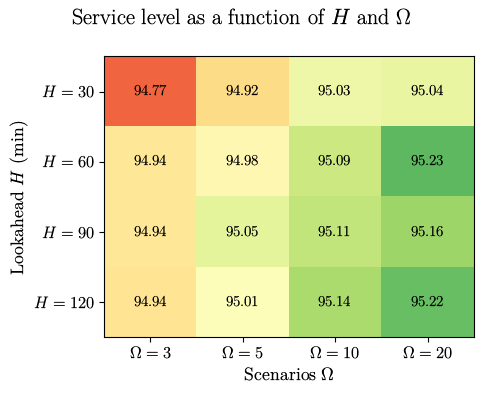

Saved phase4_step1_rt_heatmap.svg


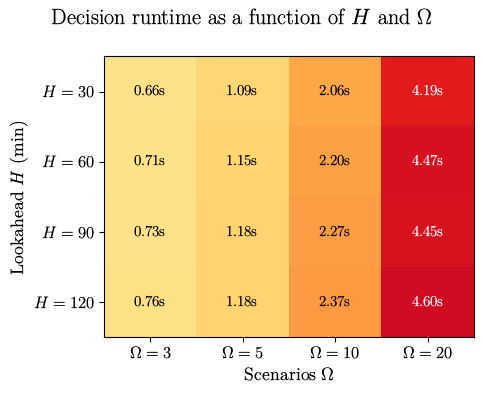

In [30]:
# ── Phase 4: Step 1 heatmaps — SL and Runtime (separate figures) ─────────
SAVE_FIG = True

# Figure 1: Service level
fig1, ax1 = plt.subplots(figsize=(5, 4))
fig1.suptitle(
    r"Service level as a function of $H$ and $\Omega$",
    fontsize=TITLE_FONTSIZE,
)
_draw_heatmap(ax1, step1_sl, h_labels, s_labels,
              lambda v: f"{v:.2f}%", "RdYlGn")
ax1.set_xlabel(r"Scenarios $\Omega$", fontsize=AXIS_FONTSIZE - 1)
ax1.set_ylabel(r"Lookahead $H$ (min)", fontsize=AXIS_FONTSIZE - 1)
fig1.tight_layout()
if SAVE_FIG:
    _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
    _PLOT_DIR.mkdir(exist_ok=True)
    fig1.savefig(_PLOT_DIR / "phase4_step1_sl_heatmap.svg", bbox_inches="tight", dpi=PLOT_DPI)
    print("Saved phase4_step1_sl_heatmap.svg")
plt.show()

# Figure 2: Runtime
fig2, ax2 = plt.subplots(figsize=(5, 4))
fig2.suptitle(
    r"Decision runtime as a function of $H$ and $\Omega$",
    fontsize=TITLE_FONTSIZE,
)
_draw_heatmap(ax2, step1_rt, h_labels, s_labels,
              lambda v: f"{v:.2f}s", "YlOrRd")
ax2.set_xlabel(r"Scenarios $\Omega$", fontsize=AXIS_FONTSIZE - 1)
ax2.set_ylabel(r"Lookahead $H$ (min)", fontsize=AXIS_FONTSIZE - 1)
fig2.tight_layout()
if SAVE_FIG:
    _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
    _PLOT_DIR.mkdir(exist_ok=True)
    fig2.savefig(_PLOT_DIR / "phase4_step1_rt_heatmap.svg", bbox_inches="tight", dpi=PLOT_DPI)
    print("Saved phase4_step1_rt_heatmap.svg")
plt.show()


Saved phase4_step2_pareto.svg


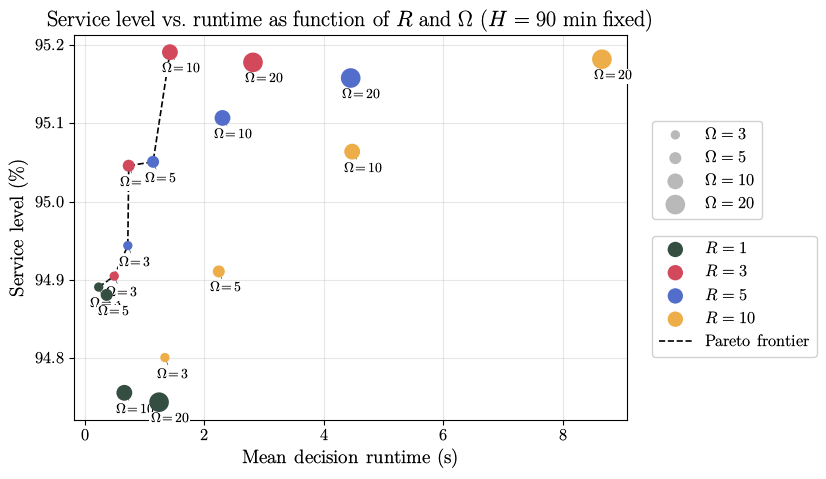

In [31]:
# ── Phase 4: Step 2 Pareto scatter only ──────────────────────────────────
SAVE_FIG = True

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title(
    r"Service level vs.\ runtime as function of $R$ and $\Omega$ ($H=90$ min fixed)",
    fontsize=TITLE_FONTSIZE,
)

all_rt, all_sl = [], []
for i, r in enumerate(PHASE4_R_VALUES):
    pts_x, pts_y, pts_sz = [], [], []
    for j, s in enumerate(PHASE4_ROUTING_S_VALUES):
        sl_v = step2_sl[i, j]
        rt_v = step2_rt[i, j]
        if not np.isnan(sl_v):
            pts_x.append(rt_v)
            pts_y.append(sl_v)
            pts_sz.append(_s_sizes.get(s, 80))
            all_rt.append(rt_v)
            all_sl.append(sl_v)
            ax.annotate(rf"$\Omega\!=\!{s}$", (rt_v, sl_v),
                        textcoords="offset points", 
                        xytext=(-6, -15),
                        fontsize=SMALL_FONTSIZE, 
                        color="#000000",
                        bbox=dict(facecolor="white", alpha=1,
                                  edgecolor="none", pad=1),
                        zorder=6,
                        arrowprops=dict(
                        arrowstyle="-",              # plain connector line
                        color="black",
                        lw=0.5,
                        alpha=0.7,
                        shrinkA=2,
                        shrinkB=3,
                    ),
                )
    ax.scatter(pts_x, pts_y, color=COLORS[i], s=pts_sz,
               label=rf"$R={r}$", alpha=1.0, edgecolors="none", zorder=7)

rts_a = np.array(all_rt)
sls_a = np.array(all_sl)
mask = _pareto_mask(rts_a, sls_a)
idx = np.argsort(rts_a[mask])
ax.plot(rts_a[mask][idx], sls_a[mask][idx],
        color="black", lw=1.2, ls="--", zorder=1, label="Pareto frontier")

ax.set_xlabel(r"Mean decision runtime (s)", fontsize=AXIS_FONTSIZE)
ax.set_ylabel(r"Service level (\%)", fontsize=AXIS_FONTSIZE)
size_handles = [ax.scatter([], [], s=_s_sizes[s], color="gray",
                           alpha=0.55, edgecolors="none")
                for s in sorted(_s_sizes)]
size_leg = ax.legend(size_handles, [rf"$\Omega={s}$" for s in sorted(_s_sizes)],
                     fontsize=LEGEND_FONTSIZE,
                     framealpha=0.9, loc="lower left",
                     bbox_to_anchor=(1.03, 0.5), bbox_transform=ax.transAxes)
ax.add_artist(size_leg)
ax.legend(fontsize=LEGEND_FONTSIZE, framealpha=0.9,
          loc="upper left", bbox_to_anchor=(1.03, 0.5),
          bbox_transform=ax.transAxes)
ax.grid(True, alpha=0.3)

fig.subplots_adjust(right=0.74)

if SAVE_FIG:
    _PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
    _PLOT_DIR.mkdir(exist_ok=True)
    fig.savefig(_PLOT_DIR / "phase4_step2_pareto.svg", bbox_inches="tight", dpi=PLOT_DPI)
    print(f"Saved phase4_step2_pareto.svg")

plt.show()


Deduplicated 1 duplicate seed row(s) at run_logs/tuning/phase4_routing_H90_RAfix/R10_S20
Saved /Users/ingvildvs/FOMOsim/policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots/phase4_routing_solution_time.svg


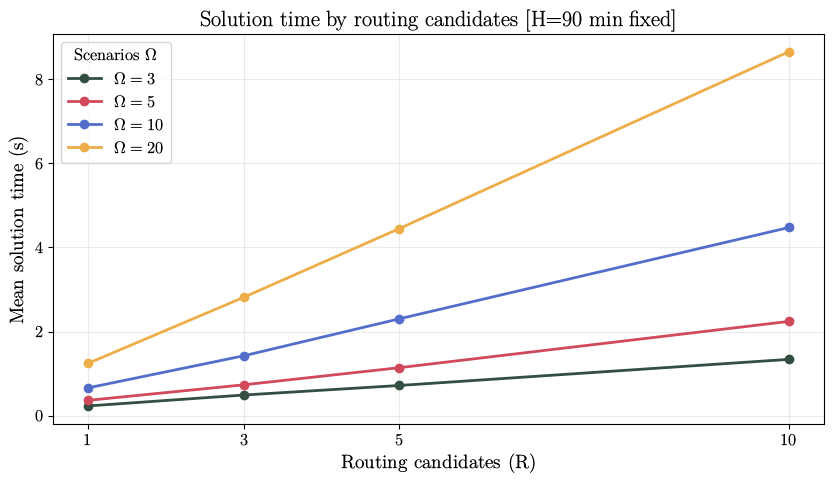

In [32]:
# ── Phase 4 Step 2: solution-time plot by routing candidates ──────────────
def phase4_routing_runtime_df(routing_logs, r_values, s_values):
    """Long-form table with mean solution time for each ($\mathcal{R}$, $\Omega$) cell."""
    rows = []
    for r in r_values:
        for s in s_values:
            _, _, _, rt = _load_cell(routing_logs.get((r, s)))
            rows.append({"R": r, "Omega": s, "mean_solution_time_s": np.nan if rt is None else rt})
    return pd.DataFrame(rows)
 
 
routing_runtime_df = phase4_routing_runtime_df(
    PHASE4_ROUTING_LOGS,
    PHASE4_R_VALUES,
    PHASE4_ROUTING_S_VALUES,
)
 
fig, ax = plt.subplots(figsize=(8.5, 5))
 
for i, s in enumerate(PHASE4_ROUTING_S_VALUES):
    series = routing_runtime_df[routing_runtime_df["Omega"] == s].sort_values("R")
    ax.plot(
        series["R"],
        series["mean_solution_time_s"],
        marker="o",
        linewidth=2.0,
        color=COLORS[i % len(COLORS)],
        label=rf"$\Omega={s}$",
    )
 
ax.set_title(
    f"Solution time by routing candidates "
    f"[H={PHASE4_ROUTING_LOOKAHEAD} min fixed]",
    fontsize=TITLE_FONTSIZE,
)
ax.set_xlabel(r"Routing candidates (R)", fontsize=AXIS_FONTSIZE)
ax.set_ylabel("Mean solution time (s)", fontsize=AXIS_FONTSIZE)
ax.set_xticks(PHASE4_R_VALUES)
ax.grid(True, alpha=0.25)
ax.legend(title=r"Scenarios $\Omega$", fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
 
_PLOT_DIR = WORKSPACE_ROOT / "policies/sjovik_sund/ablation_study/hyperparameter_tuning_plots"
_PLOT_DIR.mkdir(exist_ok=True)
_SVG_PATH = _PLOT_DIR / "phase4_routing_solution_time.svg"
fig.savefig(_SVG_PATH, format="svg", bbox_inches="tight")
print(f"Saved {_SVG_PATH}")
plt.show()
 
 

In [33]:
# ── Phase 4: Lock rollout parameters ─────────────────────────────────────
LOCKED_LOOKAHEAD  = 90   # minutes — set after inspecting grid table (Step 1)
LOCKED_SCENARIOS  = 10   # set after inspecting grid table (Step 1)
LOCKED_ROUTING    = 3    # set after routing sweep (Step 2)
print(r"Locked:  H = {LOCKED_LOOKAHEAD} min,  $\Omega$ = {LOCKED_SCENARIOS},  R = {LOCKED_ROUTING}")


Locked:  H = {LOCKED_LOOKAHEAD} min,  $\Omega$ = {LOCKED_SCENARIOS},  R = {LOCKED_ROUTING}


---
## Final Configuration Summary

In [34]:
summary_config = pd.DataFrame([
    {"Parameter": r"Feature set",          "Value": "EX15 FleetBrokenGlobal",   "Phase": "\u2014"},
    {"Parameter": r"Learning rate \u03b1", "Value": str(LOCKED_ALPHA),           "Phase": "1"},
    {"Parameter": r"Discount factor \u03b3","Value": str(LOCKED_GAMMA),          "Phase": "2"},
    {"Parameter": r"Starvation weight ws", "Value": str(LOCKED_WS),              "Phase": "3"},
    {"Parameter": r"Congestion weight wc", "Value": str(LOCKED_WC),              "Phase": "3"},
    {"Parameter": r"Lookahead H (min)",    "Value": str(LOCKED_LOOKAHEAD),       "Phase": "4"},
    {"Parameter": r"Scenarios S",          "Value": str(LOCKED_SCENARIOS),       "Phase": "4"},
    {"Parameter": r"Routing candidates R", "Value": str(LOCKED_ROUTING),         "Phase": "4"},
]).set_index("Parameter")

summary_config.style.set_caption("Final tuned configuration \u2014 EX15 FleetBrokenGlobal")

<<<<<<< local


<<<<<<< local


<<<<<<< local <modified: text/html, text/plain>


,Value,Phase
Parameter,,
Feature set,EX15 FleetBrokenGlobal,—
Learning rate \u03b1,0.1,1
Discount factor \u03b3,0.97,2
Starvation weight ws,-1.0,3
Congestion weight wc,-1.0,3
Lookahead H (min),60,4
Scenarios S,5,4
Routing candidates R,5,4


>>>>>>> remote


...

,Value,Phase
Parameter,,
Feature set,EX15 FleetBrokenGlobal,—
Learning rate \u03b1,0.1,1
Discount factor \u03b3,0.97,2
Starvation weight ws,-1.0,3
Congestion weight wc,-1.0,3
Lookahead H (min),60,4
Scenarios S,5,4
Routing candidates R,5,4


,Value,Phase
Parameter,,
Feature set,EX15 FleetBrokenGlobal,—
Learning rate \u03b1,0.1,1
Discount factor \u03b3,0.97,2
Starvation weight ws,-1.0,3
Congestion weight wc,-1.0,3
Lookahead H (min),90,4
Scenarios S,10,4
Routing candidates R,3,4


>>>>>>> remote <modified: text/html, text/plain>


>>>>>>> remote <modified: text/html, text/plain>


>>>>>>> remote <modified: text/html, text/plain>
